<a href="https://colab.research.google.com/github/Saheli04/breast-cancer-predictive-modeling/blob/main/Breast_Cancer_Wisconsin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving breast+cancer+wisconsin+diagnostic.zip to breast+cancer+wisconsin+diagnostic.zip


In [ ]:
# Extract the uploaded ZIP file

zip_file = "breast+cancer+wisconsin+diagnostic.zip"
extract_folder = "/content/breast_cancer_dataset"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
# Display extracted files

for root, dirs, files_list in os.walk(extract_folder):
    for file in files_list:
        print(os.path.join(root, file))

/content/breast_cancer_dataset/wdbc.data
/content/breast_cancer_dataset/wdbc.names


In [ ]:
# Step 2: Define column names

columns = [
    "ID",
    "Diagnosis",
    "Radius_Mean",
    "Texture_Mean",
    "Perimeter_Mean",
    "Area_Mean",
    "Smoothness_Mean",
    "Compactness_Mean",
    "Concavity_Mean",
    "Concave_Points_Mean",
    "Symmetry_Mean",
    "Fractal_Dimension_Mean",
    "Radius_SE",
    "Texture_SE",
    "Perimeter_SE",
    "Area_SE",
    "Smoothness_SE",
    "Compactness_SE",
    "Concavity_SE",
    "Concave_Points_SE",
    "Symmetry_SE",
    "Fractal_Dimension_SE",
    "Radius_Worst",
    "Texture_Worst",
    "Perimeter_Worst",
    "Area_Worst",
    "Smoothness_Worst",
    "Compactness_Worst",
    "Concavity_Worst",
    "Concave_Points_Worst",
    "Symmetry_Worst",
    "Fractal_Dimension_Worst"
]

print("Number of columns:", len(columns))

Number of columns: 32


In [ ]:
# Load the dataset

data_path = "/content/breast_cancer_dataset/wdbc.data"

df = pd.read_csv(
    data_path,
    header=None,
    names=columns
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
# Check number of rows and columns

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 569
Number of columns: 32


In [ ]:
# Display basic information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       569 non-null    int64  
 1   Diagnosis                569 non-null    object 
 2   Radius_Mean              569 non-null    float64
 3   Texture_Mean             569 non-null    float64
 4   Perimeter_Mean           569 non-null    float64
 5   Area_Mean                569 non-null    float64
 6   Smoothness_Mean          569 non-null    float64
 7   Compactness_Mean         569 non-null    float64
 8   Concavity_Mean           569 non-null    float64
 9   Concave_Points_Mean      569 non-null    float64
 10  Symmetry_Mean            569 non-null    float64
 11  Fractal_Dimension_Mean   569 non-null    float64
 12  Radius_SE                569 non-null    float64
 13  Texture_SE               569 non-null    float64
 14  Perimeter_SE             5

In [ ]:
# Count each diagnosis

print(df["Diagnosis"].value_counts())

Diagnosis
B    357
M    212
Name: count, dtype: int64


In [ ]:
# Check missing values

missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

Total missing values: 0


In [ ]:
# Check duplicate rows

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [ ]:
# Step 3: Remove unnecessary ID column

df = df.drop("ID", axis=1)

print("ID column removed.")
print("New shape:", df.shape)

ID column removed.
New shape: (569, 31)


In [ ]:
# Convert Diagnosis into numerical values

df["Diagnosis"] = df["Diagnosis"].map({
    "B": 0,
    "M": 1
})

print(df["Diagnosis"].value_counts())

Diagnosis
0    357
1    212
Name: count, dtype: int64


In [ ]:
# Check the first 10 target values

print(df["Diagnosis"].head(10))

0    1
1    1
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    1
Name: Diagnosis, dtype: int64


In [ ]:
# Display information about the cleaned dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Diagnosis                569 non-null    int64  
 1   Radius_Mean              569 non-null    float64
 2   Texture_Mean             569 non-null    float64
 3   Perimeter_Mean           569 non-null    float64
 4   Area_Mean                569 non-null    float64
 5   Smoothness_Mean          569 non-null    float64
 6   Compactness_Mean         569 non-null    float64
 7   Concavity_Mean           569 non-null    float64
 8   Concave_Points_Mean      569 non-null    float64
 9   Symmetry_Mean            569 non-null    float64
 10  Fractal_Dimension_Mean   569 non-null    float64
 11  Radius_SE                569 non-null    float64
 12  Texture_SE               569 non-null    float64
 13  Perimeter_SE             569 non-null    float64
 14  Area_SE                  5

In [ ]:
# Statistical summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diagnosis,569.0,0.372583,0.483918,0.000000,0.000000,0.000000,1.000000,1.00000
Radius_Mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
Texture_Mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
Perimeter_Mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
Area_Mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
Smoothness_Mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
Compactness_Mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
Concavity_Mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
Concave_Points_Mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
Symmetry_Mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400


In [ ]:
# Final missing-value check

print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [ ]:
# Final duplicate check

print("Total duplicate rows:", df.duplicated().sum())

Total duplicate rows: 0


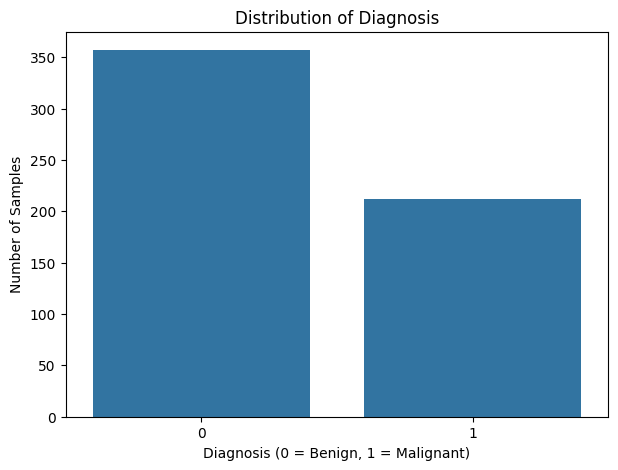

In [ ]:
# Step 4.1: Diagnosis distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    x="Diagnosis",
    data=df
)

plt.title("Distribution of Diagnosis")
plt.xlabel("Diagnosis (0 = Benign, 1 = Malignant)")
plt.ylabel("Number of Samples")

plt.show()

In [ ]:
# Calculate diagnosis percentages

diagnosis_percentage = df["Diagnosis"].value_counts(normalize=True) * 100

print("Diagnosis Distribution (%):")
print(diagnosis_percentage)

Diagnosis Distribution (%):
Diagnosis
0    62.741652
1    37.258348
Name: proportion, dtype: float64


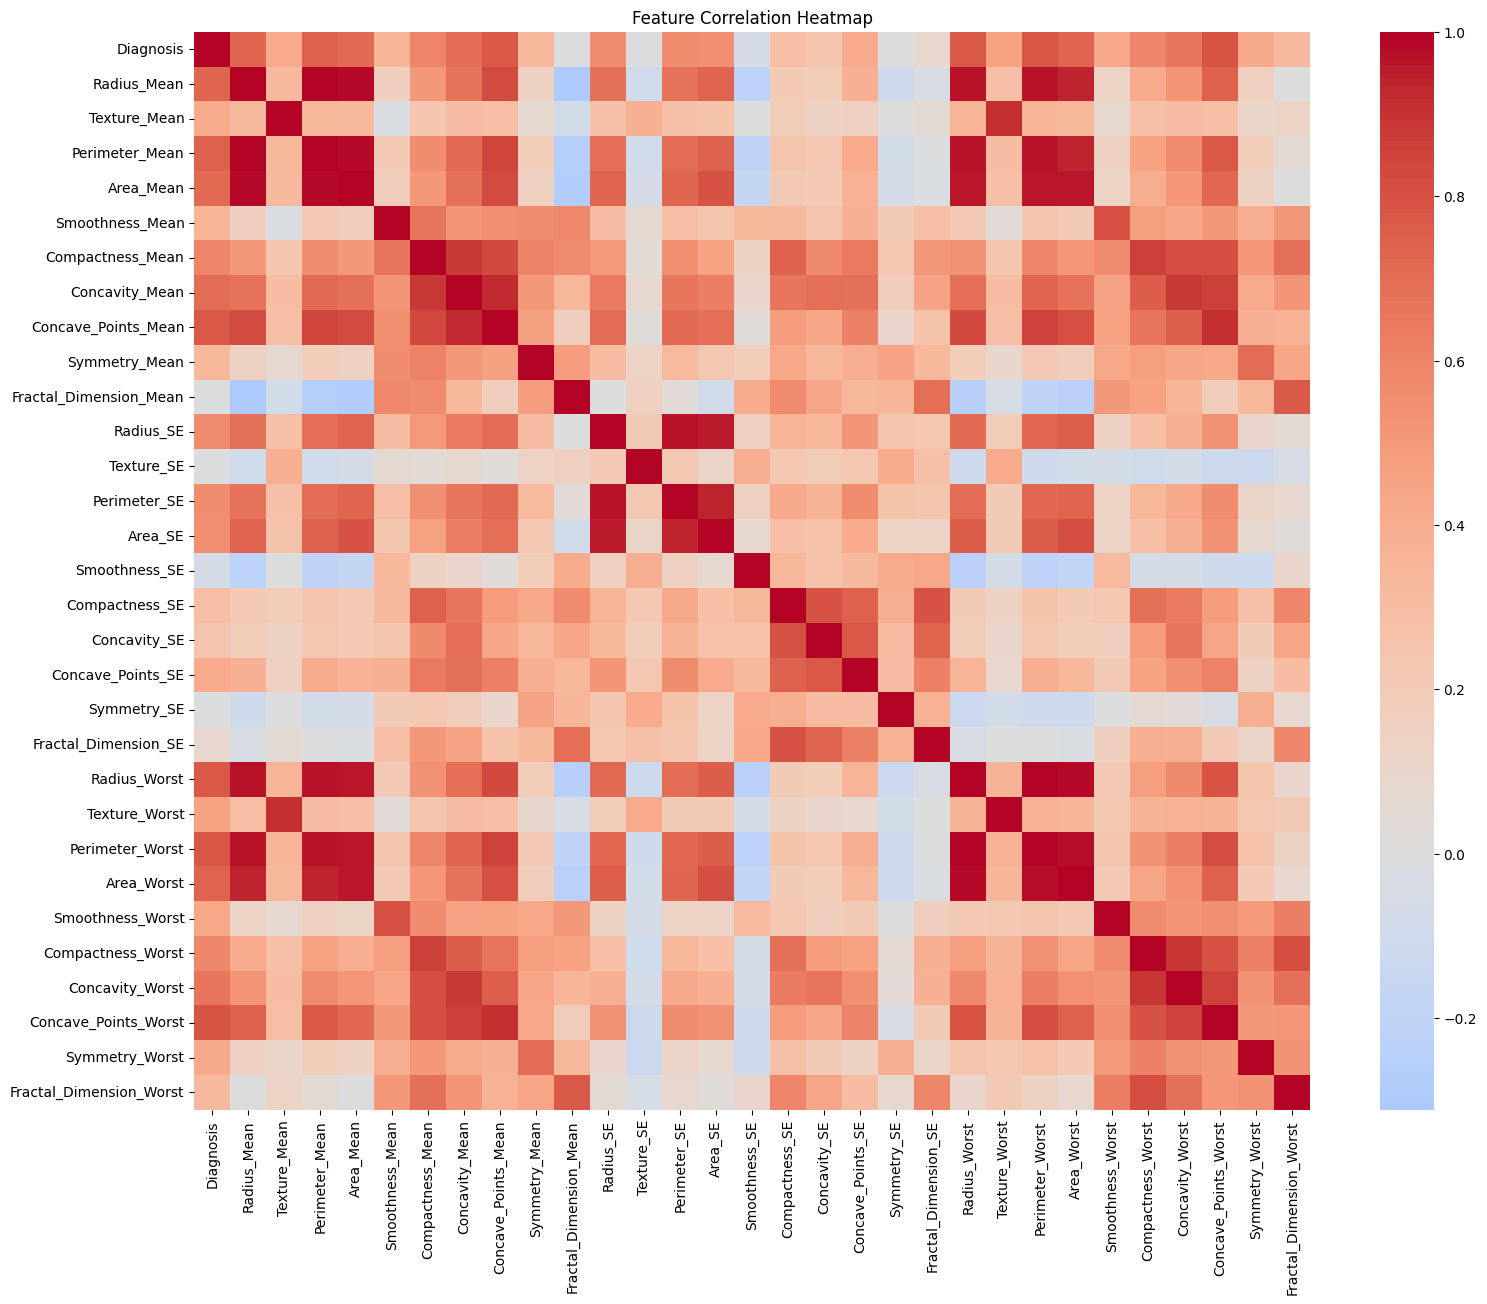

In [ ]:
# Step 4.2: Correlation heatmap

plt.figure(figsize=(18, 14))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [ ]:
# Correlation of features with Diagnosis

diagnosis_correlation = df.corr()["Diagnosis"].sort_values(
    ascending=False
)

print(diagnosis_correlation)

Diagnosis                  1.000000
Concave_Points_Worst       0.793566
Perimeter_Worst            0.782914
Concave_Points_Mean        0.776614
Radius_Worst               0.776454
Perimeter_Mean             0.742636
Area_Worst                 0.733825
Radius_Mean                0.730029
Area_Mean                  0.708984
Concavity_Mean             0.696360
Concavity_Worst            0.659610
Compactness_Mean           0.596534
Compactness_Worst          0.590998
Radius_SE                  0.567134
Perimeter_SE               0.556141
Area_SE                    0.548236
Texture_Worst              0.456903
Smoothness_Worst           0.421465
Symmetry_Worst             0.416294
Texture_Mean               0.415185
Concave_Points_SE          0.408042
Smoothness_Mean            0.358560
Symmetry_Mean              0.330499
Fractal_Dimension_Worst    0.323872
Compactness_SE             0.292999
Concavity_SE               0.253730
Fractal_Dimension_SE       0.077972
Symmetry_SE               -0

In [ ]:
# Top 10 features most positively correlated with Diagnosis

top_features = (
    df.corr()["Diagnosis"]
    .drop("Diagnosis")
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 features by absolute correlation:")
print(top_features)

Top 10 features by absolute correlation:
Concave_Points_Worst    0.793566
Perimeter_Worst         0.782914
Concave_Points_Mean     0.776614
Radius_Worst            0.776454
Perimeter_Mean          0.742636
Area_Worst              0.733825
Radius_Mean             0.730029
Area_Mean               0.708984
Concavity_Mean          0.696360
Concavity_Worst         0.659610
Name: Diagnosis, dtype: float64


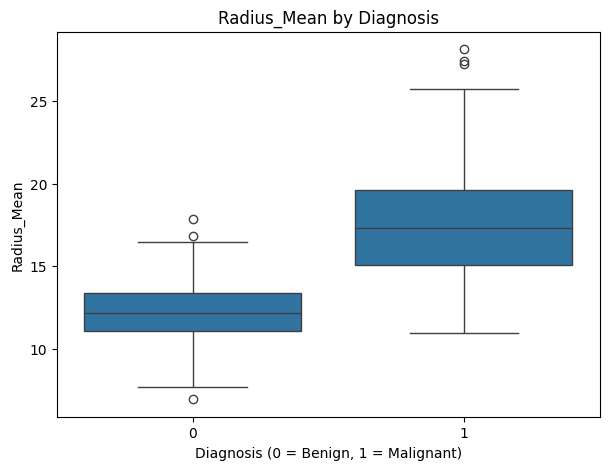

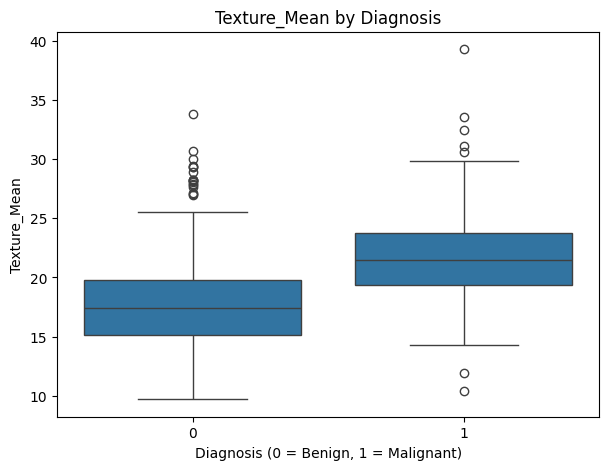

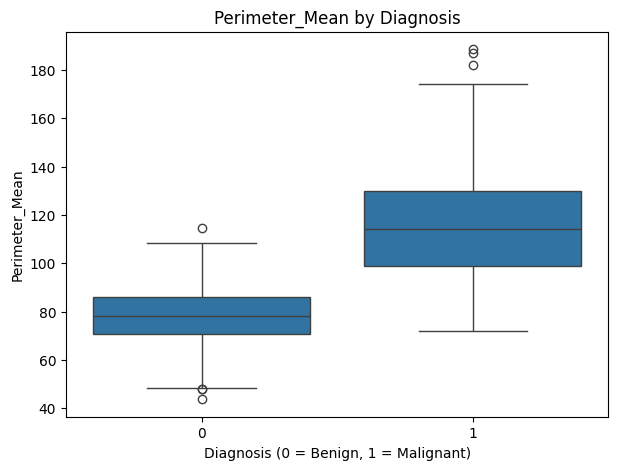

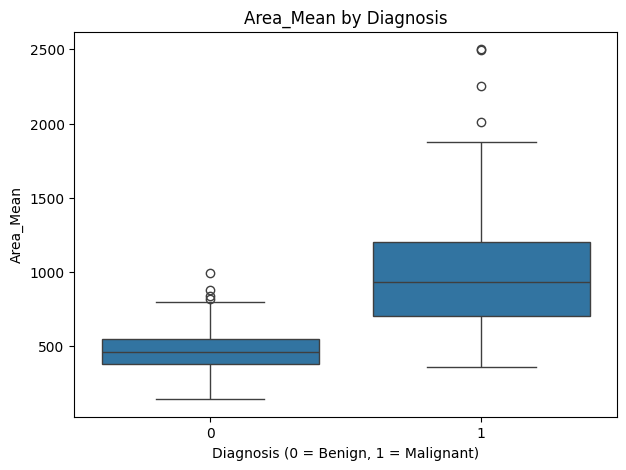

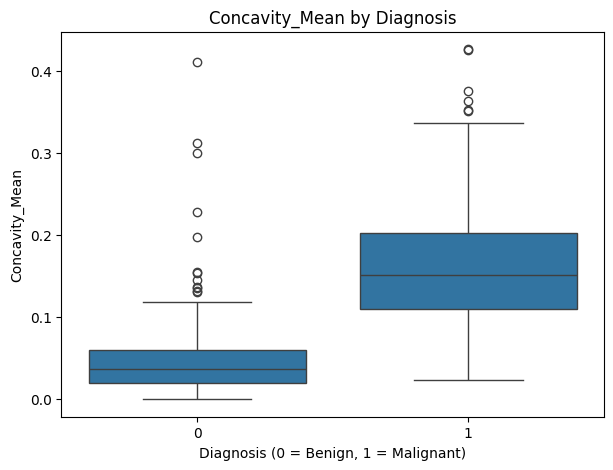

In [ ]:
# Step 4.3: Boxplots for important features

selected_features = [
    "Radius_Mean",
    "Texture_Mean",
    "Perimeter_Mean",
    "Area_Mean",
    "Concavity_Mean"
]

for feature in selected_features:

    plt.figure(figsize=(7, 5))

    sns.boxplot(
        x="Diagnosis",
        y=feature,
        data=df
    )

    plt.title(f"{feature} by Diagnosis")
    plt.xlabel("Diagnosis (0 = Benign, 1 = Malignant)")
    plt.ylabel(feature)

    plt.show()

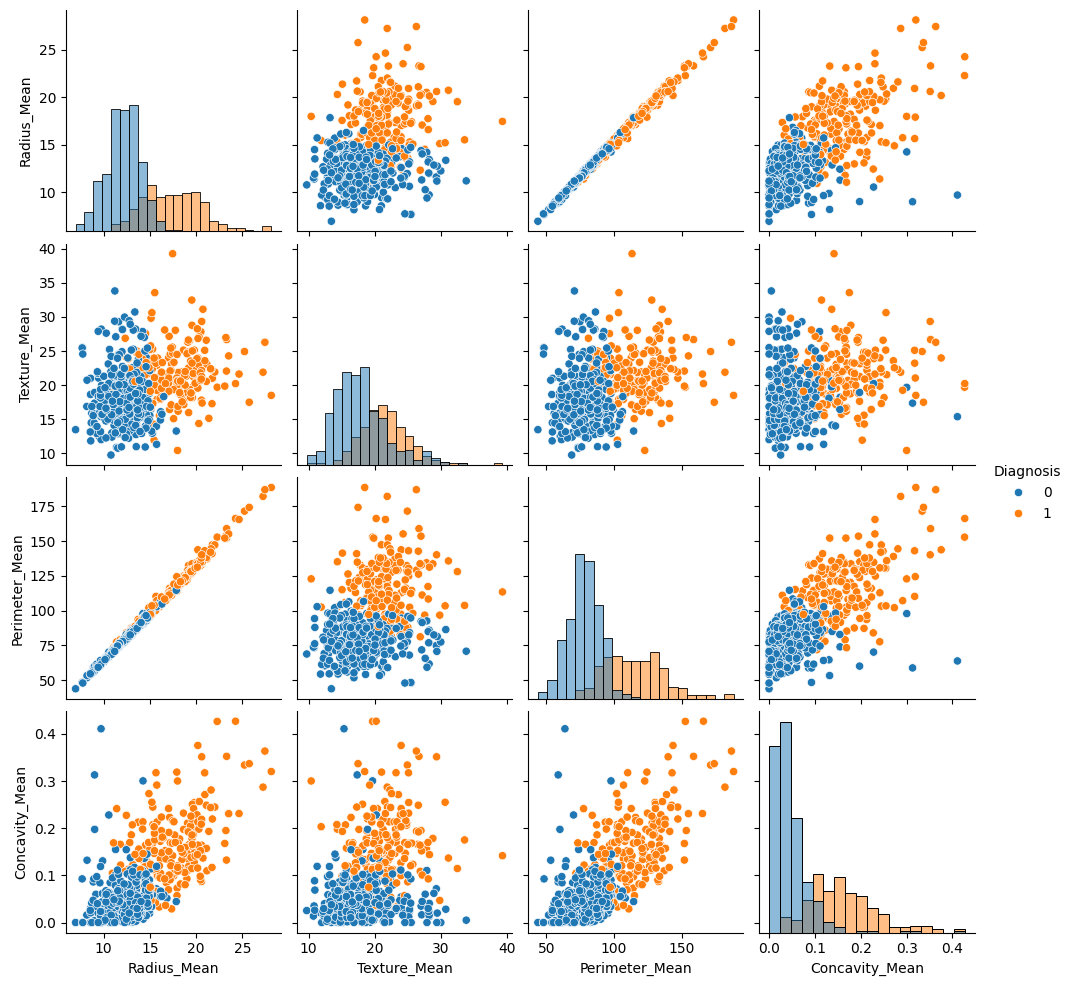

In [ ]:
# Step 4.4: Pairplot

pairplot_features = [
    "Radius_Mean",
    "Texture_Mean",
    "Perimeter_Mean",
    "Concavity_Mean",
    "Diagnosis"
]

sns.pairplot(
    df[pairplot_features],
    hue="Diagnosis",
    diag_kind="hist"
)

plt.show()

In [ ]:
# Step 5.1: Separate features and target

X = df.drop("Diagnosis", axis=1)
y = df["Diagnosis"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (569, 30)
Target shape: (569,)


In [ ]:
# Step 5.2: Train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [ ]:
# Check class distribution

print("Training set distribution:")
print(y_train.value_counts())

print("\nTesting set distribution:")
print(y_test.value_counts())

Training set distribution:
Diagnosis
0    285
1    170
Name: count, dtype: int64

Testing set distribution:
Diagnosis
0    72
1    42
Name: count, dtype: int64


In [ ]:
# Step 5.3: Feature scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [ ]:
# Check scaled training data

print("First 5 rows of scaled training data:")
print(X_train_scaled[:5])

First 5 rows of scaled training data:
[[ 5.18558727e-01  8.91825791e-01  4.24631702e-01  3.83925436e-01
  -9.74743706e-01 -6.89771505e-01 -6.88586446e-01 -3.98175254e-01
  -1.03915470e+00 -8.25056321e-01 -1.09317755e-01 -5.59755400e-02
  -2.10096206e-01 -1.59132582e-02 -1.00518399e+00 -9.11941990e-01
  -6.62815884e-01 -6.52561081e-01 -7.01889114e-01 -2.75393571e-01
   5.79797697e-01  1.31324246e+00  4.66908134e-01  4.45982711e-01
  -5.96154777e-01 -6.34722227e-01 -6.10227299e-01 -2.35743918e-01
   5.45663235e-02  2.18367276e-02]
 [-5.16364088e-01 -1.63971029e+00 -5.41348716e-01 -5.42961327e-01
   4.76219058e-01 -6.31833818e-01 -6.04281166e-01 -3.03074908e-01
   5.21543093e-01 -4.54522896e-01 -6.04377961e-01 -1.00104604e+00
  -5.85429002e-01 -4.93453793e-01  4.03212009e-01 -7.68173276e-01
  -4.79187222e-01  1.14508478e-01 -1.42950761e-01 -5.77397732e-01
  -5.82458953e-01 -1.69029101e+00 -6.11934288e-01 -5.87013537e-01
   2.73581959e-01 -8.14844486e-01 -7.12666415e-01 -3.23207881e-01
  -

In [ ]:
# Verify scaling

print("Mean of first feature:", X_train_scaled[:, 0].mean())
print("Standard deviation of first feature:", X_train_scaled[:, 0].std())

Mean of first feature: -1.737316029743102e-16
Standard deviation of first feature: 1.0


In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(random_state=42, max_iter=1000)

print("Logistic Regression model created successfully!")

Logistic Regression model created successfully!


In [ ]:
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [ ]:
y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Predictions generated successfully!")
print("First 20 predictions:")
print(y_pred_logistic[:20])

Predictions generated successfully!
First 20 predictions:
[0 1 0 1 1 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0]


In [ ]:
y_prob_logistic = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Prediction probabilities generated successfully!")
print("First 10 probabilities:")
print(y_prob_logistic[:10])

Prediction probabilities generated successfully!
First 10 probabilities:
[3.64568116e-04 9.99999989e-01 4.25679471e-02 5.76187322e-01
 5.09155489e-01 6.16001620e-04 7.61534086e-01 1.01217174e-03
 5.68725516e-04 1.07675795e-02]


In [ ]:
from sklearn.metrics import accuracy_score

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", logistic_accuracy)
print("Accuracy (%):", logistic_accuracy * 100)

Logistic Regression Accuracy: 0.9649122807017544
Accuracy (%): 96.49122807017544


In [ ]:
from sklearn.metrics import classification_report

print("Logistic Regression Classification Report:")
print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=["Benign", "Malignant"]
))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [ ]:
from sklearn.metrics import confusion_matrix

cm_logistic = confusion_matrix(y_test, y_pred_logistic)

print("Confusion Matrix:")
print(cm_logistic)

Confusion Matrix:
[[71  1]
 [ 3 39]]


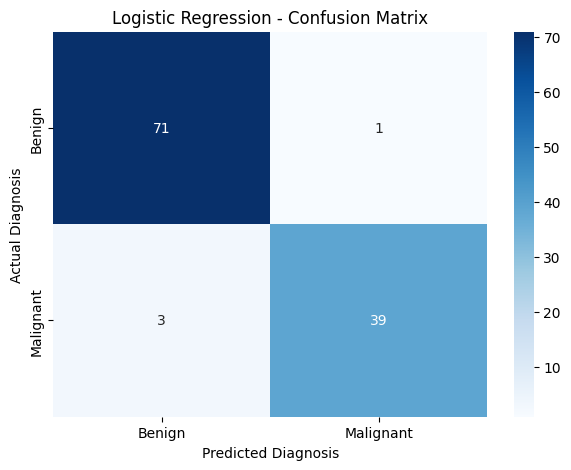

In [ ]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Diagnosis")
plt.ylabel("Actual Diagnosis")

plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

logistic_auc = roc_auc_score(y_test, y_prob_logistic)

print("Logistic Regression ROC-AUC:", logistic_auc)

Logistic Regression ROC-AUC: 0.996031746031746


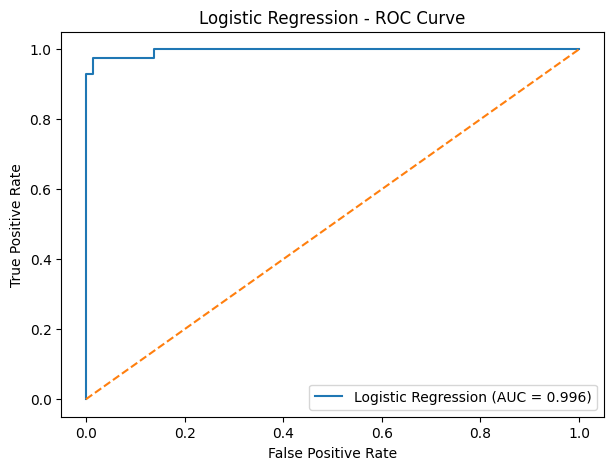

In [ ]:
from sklearn.metrics import roc_curve

fpr_logistic, tpr_logistic, thresholds_logistic = roc_curve(
    y_test,
    y_prob_logistic
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression - ROC Curve")
plt.legend()

plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

print("Decision Tree model created successfully!")

Decision Tree model created successfully!


In [ ]:
decision_tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [ ]:
y_pred_tree = decision_tree_model.predict(X_test)

print("Decision Tree predictions generated successfully!")
print("First 20 predictions:")
print(y_pred_tree[:20])

Decision Tree predictions generated successfully!
First 20 predictions:
[0 1 1 1 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0 0]


In [ ]:
y_prob_tree = decision_tree_model.predict_proba(X_test)[:, 1]

print("Decision Tree prediction probabilities generated successfully!")
print("First 10 probabilities:")
print(y_prob_tree[:10])

Decision Tree prediction probabilities generated successfully!
First 10 probabilities:
[0. 1. 1. 1. 0. 0. 1. 0. 0. 0.]


In [ ]:
from sklearn.metrics import accuracy_score

tree_accuracy = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", tree_accuracy)
print("Accuracy (%):", tree_accuracy * 100)

Decision Tree Accuracy: 0.9298245614035088
Accuracy (%): 92.98245614035088


In [ ]:
from sklearn.metrics import classification_report

print("Decision Tree Classification Report:")
print(classification_report(
    y_test,
    y_pred_tree,
    target_names=["Benign", "Malignant"]
))

Decision Tree Classification Report:
              precision    recall  f1-score   support

      Benign       0.94      0.94      0.94        72
   Malignant       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [ ]:
from sklearn.metrics import confusion_matrix

cm_tree = confusion_matrix(y_test, y_pred_tree)

print("Decision Tree Confusion Matrix:")
print(cm_tree)

Decision Tree Confusion Matrix:
[[68  4]
 [ 4 38]]


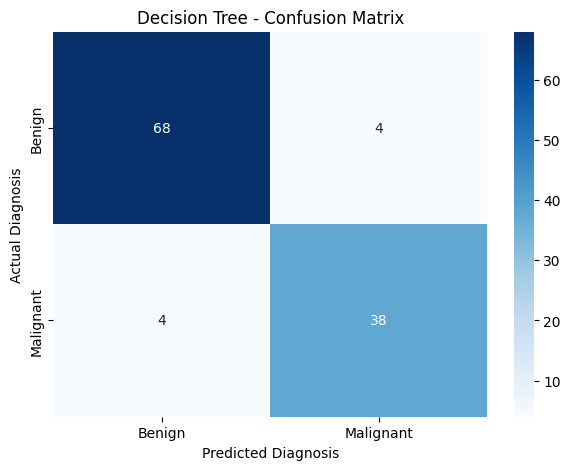

In [ ]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Diagnosis")
plt.ylabel("Actual Diagnosis")

plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

tree_auc = roc_auc_score(y_test, y_prob_tree)

print("Decision Tree ROC-AUC:", tree_auc)

Decision Tree ROC-AUC: 0.9246031746031745


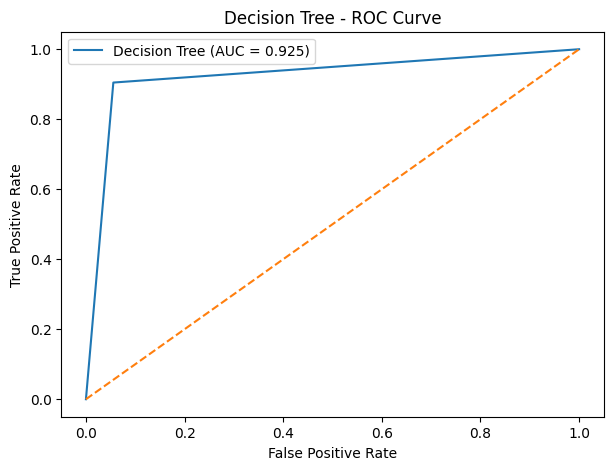

In [ ]:
from sklearn.metrics import roc_curve

fpr_tree, tpr_tree, thresholds_tree = roc_curve(
    y_test,
    y_prob_tree
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC = {tree_auc:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree - ROC Curve")
plt.legend()

plt.show()

In [ ]:
print("Decision Tree Evaluation Complete!")
print("Accuracy:", tree_accuracy)
print("ROC-AUC:", tree_auc)

Decision Tree Evaluation Complete!
Accuracy: 0.9298245614035088
ROC-AUC: 0.9246031746031745


In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [ ]:
random_forest_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
y_pred_forest = random_forest_model.predict(X_test)

print("Random Forest predictions generated successfully!")
print("First 20 predictions:")
print(y_pred_forest[:20])

Random Forest predictions generated successfully!
First 20 predictions:
[0 1 0 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0]


In [ ]:
y_prob_forest = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest prediction probabilities generated successfully!")
print("First 10 probabilities:")
print(y_prob_forest[:10])

Random Forest prediction probabilities generated successfully!
First 10 probabilities:
[0.01 1.   0.34 0.63 0.09 0.06 0.66 0.16 0.   0.  ]


In [ ]:
forest_accuracy = accuracy_score(y_test, y_pred_forest)

print("Random Forest Accuracy:", forest_accuracy)
print("Accuracy (%):", forest_accuracy * 100)

Random Forest Accuracy: 0.9736842105263158
Accuracy (%): 97.36842105263158


In [ ]:
print("Random Forest Classification Report:")
print(classification_report(
    y_test,
    y_pred_forest,
    target_names=["Benign", "Malignant"]
))

Random Forest Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [ ]:
cm_forest = confusion_matrix(y_test, y_pred_forest)

print("Random Forest Confusion Matrix:")
print(cm_forest)

Random Forest Confusion Matrix:
[[72  0]
 [ 3 39]]


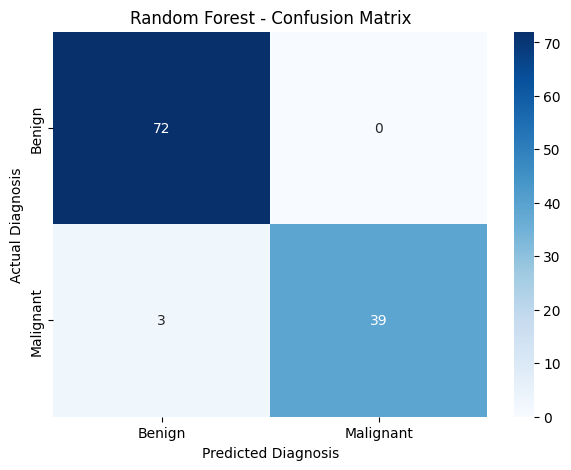

In [ ]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_forest,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Diagnosis")
plt.ylabel("Actual Diagnosis")

plt.show()

In [ ]:
forest_auc = roc_auc_score(y_test, y_prob_forest)

print("Random Forest ROC-AUC:", forest_auc)

Random Forest ROC-AUC: 0.9928902116402116


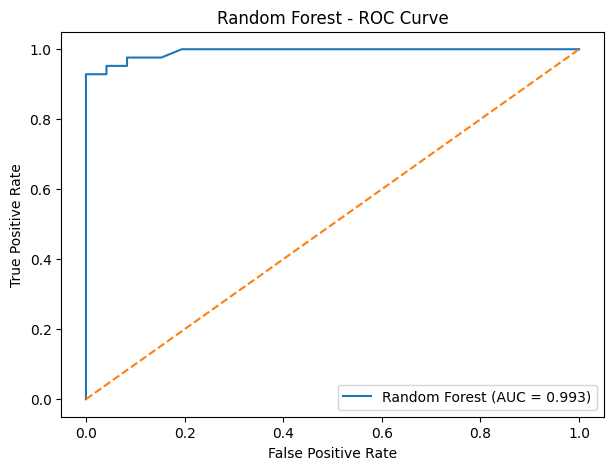

In [ ]:
fpr_forest, tpr_forest, thresholds_forest = roc_curve(
    y_test,
    y_prob_forest
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr_forest,
    tpr_forest,
    label=f"Random Forest (AUC = {forest_auc:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest - ROC Curve")
plt.legend()

plt.show()

In [ ]:
print("Random Forest Evaluation Complete!")
print("Accuracy:", forest_accuracy)
print("ROC-AUC:", forest_auc)

Random Forest Evaluation Complete!
Accuracy: 0.9736842105263158
ROC-AUC: 0.9928902116402116


In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        forest_accuracy
    ],
    "ROC-AUC": [
        logistic_auc,
        tree_auc,
        forest_auc
    ]
})

model_comparison

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.964912,0.996032
1,Decision Tree,0.929825,0.924603
2,Random Forest,0.973684,0.992890


In [ ]:
model_comparison["Accuracy (%)"] = (
    model_comparison["Accuracy"] * 100
)

model_comparison["ROC-AUC"] = (
    model_comparison["ROC-AUC"].round(4)
)

model_comparison

,Model,Accuracy,ROC-AUC,Accuracy (%)
0,Logistic Regression,0.964912,0.9960,96.491228
1,Decision Tree,0.929825,0.9246,92.982456
2,Random Forest,0.973684,0.9929,97.368421


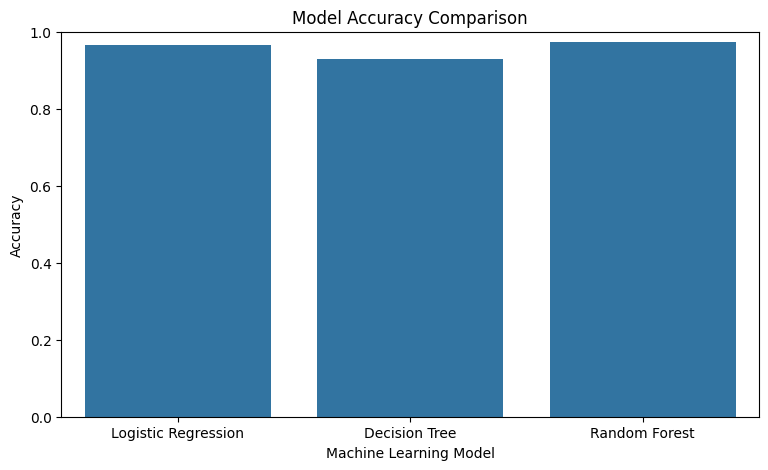

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.show()

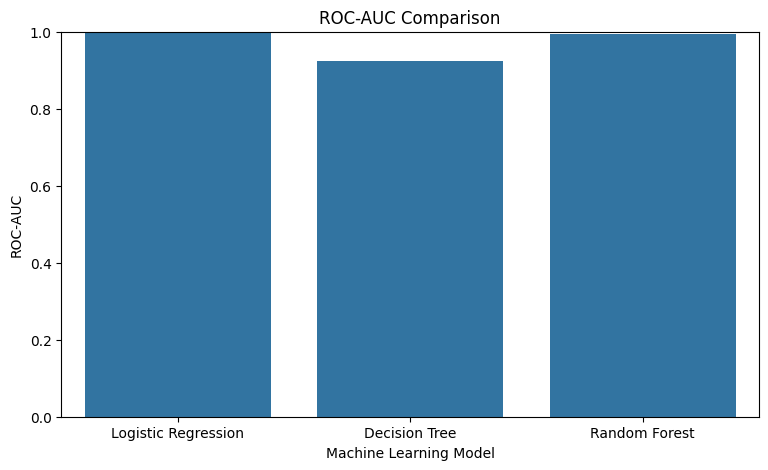

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="ROC-AUC"
)

plt.title("ROC-AUC Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("ROC-AUC")

plt.ylim(0, 1)

plt.show()

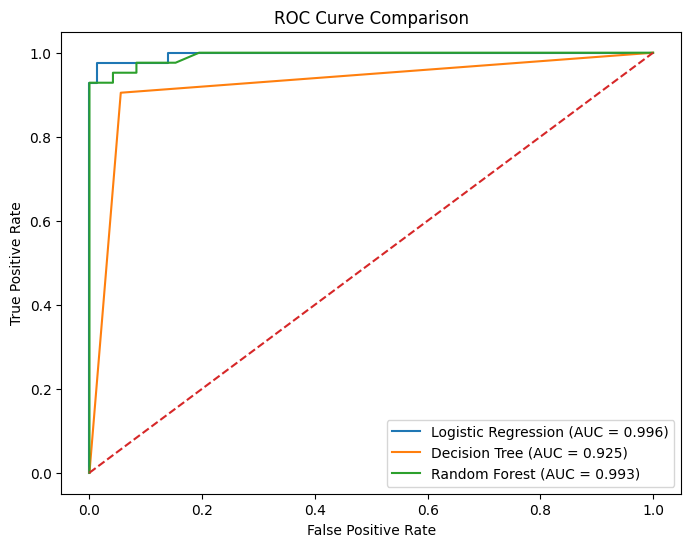

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC = {tree_auc:.3f})"
)

plt.plot(
    fpr_forest,
    tpr_forest,
    label=f"Random Forest (AUC = {forest_auc:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [ ]:
print("FINAL MODEL COMPARISON")
print("=" * 50)

print(model_comparison.to_string(index=False))

FINAL MODEL COMPARISON
              Model  Accuracy  ROC-AUC  Accuracy (%)
Logistic Regression  0.964912   0.9960     96.491228
      Decision Tree  0.929825   0.9246     92.982456
      Random Forest  0.973684   0.9929     97.368421


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_forest)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_forest)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_forest)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_forest)
    ],
    "ROC-AUC": [
        logistic_auc,
        tree_auc,
        forest_auc
    ]
})

metrics_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9649,0.9750,0.9286,0.9512,0.9960
1,Decision Tree,0.9298,0.9048,0.9048,0.9048,0.9246
2,Random Forest,0.9737,1.0000,0.9286,0.9630,0.9929


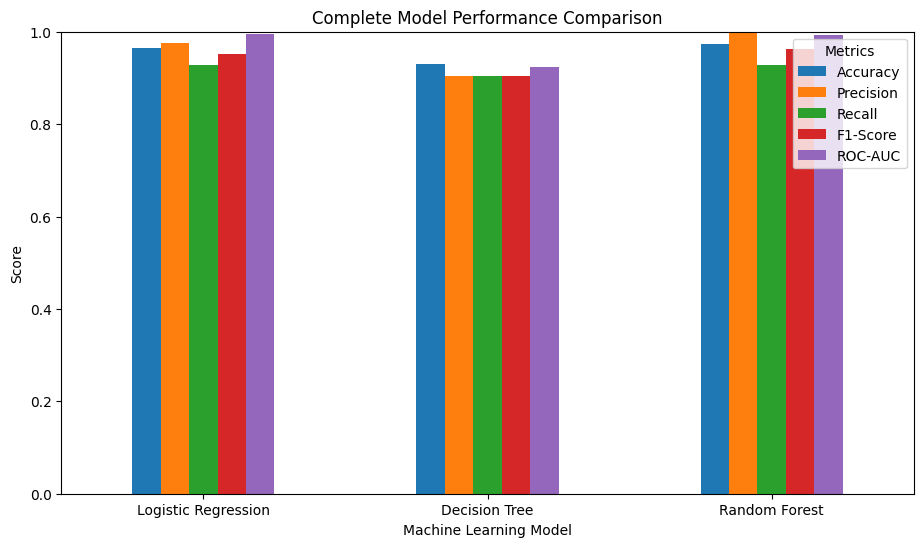

In [ ]:
metrics_plot = metrics_comparison.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
]

metrics_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Complete Model Performance Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
23,Area_Worst,0.151412
27,Concave_Points_Worst,0.126497
20,Radius_Worst,0.093475
22,Perimeter_Worst,0.083642
7,Concave_Points_Mean,0.081082
2,Perimeter_Mean,0.077126
0,Radius_Mean,0.061990
6,Concavity_Mean,0.050818
3,Area_Mean,0.045916
26,Concavity_Worst,0.030022


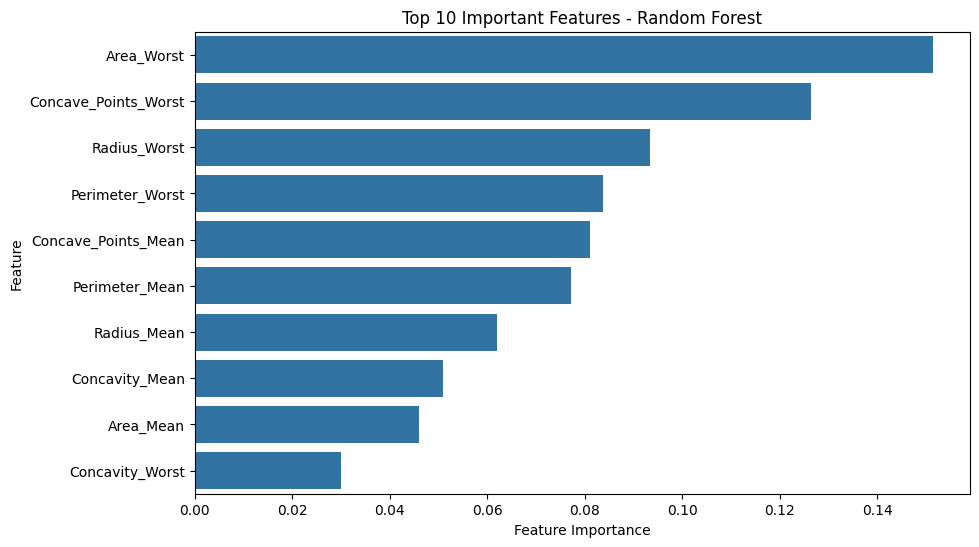

In [ ]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
print("Top 10 Important Features:")
print("=" * 50)

for index, row in top_features.iterrows():
    print(
        f"{row['Feature']}: "
        f"{row['Importance']:.4f}"
    )

Top 10 Important Features:
Area_Worst: 0.1514
Concave_Points_Worst: 0.1265
Radius_Worst: 0.0935
Perimeter_Worst: 0.0836
Concave_Points_Mean: 0.0811
Perimeter_Mean: 0.0771
Radius_Mean: 0.0620
Concavity_Mean: 0.0508
Area_Mean: 0.0459
Concavity_Worst: 0.0300


In [ ]:
metrics_comparison.to_csv(
    "breast_cancer_model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


In [ ]:
feature_importance.to_csv(
    "random_forest_feature_importance.csv",
    index=False
)

print("Feature importance saved successfully!")

Feature importance saved successfully!


In [ ]:
# Select the Random Forest model for final prediction

final_model = random_forest_model

print("Final model selected: Random Forest")

Final model selected: Random Forest


In [ ]:
# Take one sample from the test dataset

sample = X_test.iloc[[0]]

print("Sample feature values:")
display(sample)

Sample feature values:


,Radius_Mean,Texture_Mean,Perimeter_Mean,Area_Mean,Smoothness_Mean,Compactness_Mean,Concavity_Mean,Concave_Points_Mean,Symmetry_Mean,Fractal_Dimension_Mean,...,Radius_Worst,Texture_Worst,Perimeter_Worst,Area_Worst,Smoothness_Worst,Compactness_Worst,Concavity_Worst,Concave_Points_Worst,Symmetry_Worst,Fractal_Dimension_Worst
120,11.41,10.82,73.34,403.3,0.09373,0.06685,0.03512,0.02623,0.1667,0.06113,...,12.82,15.97,83.74,510.5,0.1548,0.239,0.2102,0.08958,0.3016,0.08523


In [ ]:
# Predict the diagnosis

sample_prediction = final_model.predict(sample)[0]
sample_probability = final_model.predict_proba(sample)[0]

if sample_prediction == 0:
    diagnosis = "Benign"
else:
    diagnosis = "Malignant"

print("Predicted Diagnosis:", diagnosis)
print("Probability of Benign:", round(sample_probability[0] * 100, 2), "%")
print("Probability of Malignant:", round(sample_probability[1] * 100, 2), "%")

Predicted Diagnosis: Benign
Probability of Benign: 99.0 %
Probability of Malignant: 1.0 %


In [ ]:
# Compare prediction with the actual diagnosis

actual_value = y_test.iloc[0]

if actual_value == 0:
    actual_diagnosis = "Benign"
else:
    actual_diagnosis = "Malignant"

print("Predicted Diagnosis:", diagnosis)
print("Actual Diagnosis:", actual_diagnosis)

Predicted Diagnosis: Benign
Actual Diagnosis: Benign


In [ ]:
print("FINAL PROJECT SUMMARY")
print("=" * 60)

print("Dataset: Breast Cancer Wisconsin (Diagnostic)")
print("Number of Samples:", len(df))
print("Number of Features:", X.shape[1])
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

print("\nModel Performance:")
print(metrics_comparison.round(4).to_string(index=False))

FINAL PROJECT SUMMARY
Dataset: Breast Cancer Wisconsin (Diagnostic)
Number of Samples: 569
Number of Features: 30
Training Samples: 455
Testing Samples: 114

Model Performance:
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.9649     0.9750  0.9286    0.9512   0.9960
      Decision Tree    0.9298     0.9048  0.9048    0.9048   0.9246
      Random Forest    0.9737     1.0000  0.9286    0.9630   0.9929


In [ ]:
print("PROJECT COMPLETED SUCCESSFULLY!")
print("=" * 60)

print("""
The project included:

1. Dataset loading and preprocessing
2. Exploratory Data Analysis
3. Data cleaning and validation
4. Train-test splitting
5. Feature scaling
6. Logistic Regression
7. Decision Tree
8. Random Forest
9. Accuracy evaluation
10. Precision, Recall and F1-score
11. Confusion matrices
12. ROC-AUC evaluation
13. ROC curve comparison
14. Feature importance analysis
15. Prediction on a new sample
""")

PROJECT COMPLETED SUCCESSFULLY!

The project included:

1. Dataset loading and preprocessing
2. Exploratory Data Analysis
3. Data cleaning and validation
4. Train-test splitting
5. Feature scaling
6. Logistic Regression
7. Decision Tree
8. Random Forest
9. Accuracy evaluation
10. Precision, Recall and F1-score
11. Confusion matrices
12. ROC-AUC evaluation
13. ROC curve comparison
14. Feature importance analysis
15. Prediction on a new sample



In [ ]:
final_results = metrics_comparison.copy()

final_results["Accuracy (%)"] = (
    final_results["Accuracy"] * 100
).round(2)

final_results["Precision (%)"] = (
    final_results["Precision"] * 100
).round(2)

final_results["Recall (%)"] = (
    final_results["Recall"] * 100
).round(2)

final_results["F1-Score (%)"] = (
    final_results["F1-Score"] * 100
).round(2)

final_results["ROC-AUC"] = (
    final_results["ROC-AUC"].round(4)
)

final_results = final_results[
    [
        "Model",
        "Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "F1-Score (%)",
        "ROC-AUC"
    ]
]

final_results

,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%),ROC-AUC
0,Logistic Regression,96.49,97.50,92.86,95.12,0.9960
1,Decision Tree,92.98,90.48,90.48,90.48,0.9246
2,Random Forest,97.37,100.00,92.86,96.30,0.9929


In [ ]:
print("FINAL RESULTS TABLE")
print("=" * 80)
print(final_results.to_string(index=False))

FINAL RESULTS TABLE
              Model  Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)  ROC-AUC
Logistic Regression         96.49          97.50       92.86         95.12   0.9960
      Decision Tree         92.98          90.48       90.48         90.48   0.9246
      Random Forest         97.37         100.00       92.86         96.30   0.9929


In [ ]:
final_results.to_csv(
    "final_breast_cancer_results.csv",
    index=False
)

print("Final results saved successfully!")

Final results saved successfully!


In [ ]:
from IPython.display import FileLink

FileLink("final_breast_cancer_results.csv")

/content/final_breast_cancer_results.csv

In [ ]:
print("""
PROJECT CONCLUSION
==================

Machine learning classification models were successfully developed
using the Breast Cancer Wisconsin (Diagnostic) dataset.

Logistic Regression, Decision Tree, and Random Forest models were
trained and evaluated using Accuracy, Precision, Recall, F1-Score,
ROC-AUC, confusion matrices, and ROC curves.

The analysis demonstrates how machine learning can be used to classify
breast tumor cases as benign or malignant based on diagnostic features.

Feature importance analysis was also performed using the Random Forest
model to identify the features that contributed most to the predictions.

The project successfully demonstrates the complete machine learning
workflow from data preprocessing and exploratory analysis to model
training, evaluation, comparison, and prediction.
""")


PROJECT CONCLUSION

Machine learning classification models were successfully developed
using the Breast Cancer Wisconsin (Diagnostic) dataset.

Logistic Regression, Decision Tree, and Random Forest models were
trained and evaluated using Accuracy, Precision, Recall, F1-Score,
ROC-AUC, confusion matrices, and ROC curves.

The analysis demonstrates how machine learning can be used to classify
breast tumor cases as benign or malignant based on diagnostic features.

Feature importance analysis was also performed using the Random Forest
model to identify the features that contributed most to the predictions.

The project successfully demonstrates the complete machine learning
workflow from data preprocessing and exploratory analysis to model
training, evaluation, comparison, and prediction.



In [ ]:
# Create a complete dataset for Power BI / Tableau

dashboard_data = X.copy()

dashboard_data["Diagnosis"] = y

dashboard_data["Diagnosis_Label"] = dashboard_data["Diagnosis"].map({
    0: "Benign",
    1: "Malignant"
})

dashboard_data.head()

,Radius_Mean,Texture_Mean,Perimeter_Mean,Area_Mean,Smoothness_Mean,Compactness_Mean,Concavity_Mean,Concave_Points_Mean,Symmetry_Mean,Fractal_Dimension_Mean,...,Perimeter_Worst,Area_Worst,Smoothness_Worst,Compactness_Worst,Concavity_Worst,Concave_Points_Worst,Symmetry_Worst,Fractal_Dimension_Worst,Diagnosis,Diagnosis_Label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1,Malignant


In [ ]:
# Create predictions for all test samples

dashboard_predictions = X_test.copy()

dashboard_predictions["Actual"] = y_test.values

dashboard_predictions["Actual_Label"] = y_test.map({
    0: "Benign",
    1: "Malignant"
}).values

dashboard_predictions["Logistic_Prediction"] = y_pred_logistic
dashboard_predictions["Tree_Prediction"] = y_pred_tree
dashboard_predictions["Random_Forest_Prediction"] = y_pred_forest

dashboard_predictions["Logistic_Label"] = np.where(
    dashboard_predictions["Logistic_Prediction"] == 0,
    "Benign",
    "Malignant"
)

dashboard_predictions["Tree_Label"] = np.where(
    dashboard_predictions["Tree_Prediction"] == 0,
    "Benign",
    "Malignant"
)

dashboard_predictions["Random_Forest_Label"] = np.where(
    dashboard_predictions["Random_Forest_Prediction"] == 0,
    "Benign",
    "Malignant"
)

dashboard_predictions.head()

,Radius_Mean,Texture_Mean,Perimeter_Mean,Area_Mean,Smoothness_Mean,Compactness_Mean,Concavity_Mean,Concave_Points_Mean,Symmetry_Mean,Fractal_Dimension_Mean,...,Symmetry_Worst,Fractal_Dimension_Worst,Actual,Actual_Label,Logistic_Prediction,Tree_Prediction,Random_Forest_Prediction,Logistic_Label,Tree_Label,Random_Forest_Label
120,11.41,10.82,73.34,403.3,0.09373,0.06685,0.03512,0.02623,0.1667,0.06113,...,0.3016,0.08523,0,Benign,0,0,0,Benign,Benign,Benign
250,20.94,23.56,138.90,1364.0,0.10070,0.16060,0.27120,0.13100,0.2205,0.05898,...,0.3126,0.07849,1,Malignant,1,1,1,Malignant,Malignant,Malignant
375,16.17,16.07,106.30,788.5,0.09880,0.14380,0.06651,0.05397,0.1990,0.06572,...,0.3153,0.08960,0,Benign,0,1,0,Benign,Malignant,Benign
99,14.42,19.77,94.48,642.5,0.09752,0.11410,0.09388,0.05839,0.1879,0.06390,...,0.2718,0.09353,1,Malignant,1,1,1,Malignant,Malignant,Malignant
455,13.38,30.72,86.34,557.2,0.09245,0.07426,0.02819,0.03264,0.1375,0.06016,...,0.2196,0.07675,0,Benign,1,0,0,Malignant,Benign,Benign


In [ ]:
powerbi_model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy,
        forest_accuracy
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_forest)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_forest)
    ],
    "F1_Score": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_forest)
    ],
    "ROC_AUC": [
        logistic_auc,
        tree_auc,
        forest_auc
    ]
})

powerbi_model_results

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.964912,0.975000,0.928571,0.951220,0.996032
1,Decision Tree,0.929825,0.904762,0.904762,0.904762,0.924603
2,Random Forest,0.973684,1.000000,0.928571,0.962963,0.992890


In [ ]:
confusion_data = pd.DataFrame({
    "Model": (
        ["Logistic Regression"] * 4 +
        ["Decision Tree"] * 4 +
        ["Random Forest"] * 4
    ),
    "Actual": (
        ["Benign", "Benign", "Malignant", "Malignant"] * 3
    ),
    "Predicted": (
        ["Benign", "Malignant", "Benign", "Malignant"] * 3
    ),
    "Count": [
        cm_logistic[0, 0],
        cm_logistic[0, 1],
        cm_logistic[1, 0],
        cm_logistic[1, 1],

        cm_tree[0, 0],
        cm_tree[0, 1],
        cm_tree[1, 0],
        cm_tree[1, 1],

        cm_forest[0, 0],
        cm_forest[0, 1],
        cm_forest[1, 0],
        cm_forest[1, 1]
    ]
})

confusion_data

,Model,Actual,Predicted,Count
0,Logistic Regression,Benign,Benign,71
1,Logistic Regression,Benign,Malignant,1
2,Logistic Regression,Malignant,Benign,3
3,Logistic Regression,Malignant,Malignant,39
4,Decision Tree,Benign,Benign,68
5,Decision Tree,Benign,Malignant,4
6,Decision Tree,Malignant,Benign,4
7,Decision Tree,Malignant,Malignant,38
8,Random Forest,Benign,Benign,72
9,Random Forest,Benign,Malignant,0


In [ ]:
roc_data = pd.DataFrame({
    "Model": (
        ["Logistic Regression"] * len(fpr_logistic) +
        ["Decision Tree"] * len(fpr_tree) +
        ["Random Forest"] * len(fpr_forest)
    ),
    "False_Positive_Rate": np.concatenate([
        fpr_logistic,
        fpr_tree,
        fpr_forest
    ]),
    "True_Positive_Rate": np.concatenate([
        tpr_logistic,
        tpr_tree,
        tpr_forest
    ])
})

roc_data.head()

,Model,False_Positive_Rate,True_Positive_Rate
0,Logistic Regression,0.000000,0.000000
1,Logistic Regression,0.000000,0.023810
2,Logistic Regression,0.000000,0.928571
3,Logistic Regression,0.013889,0.928571
4,Logistic Regression,0.013889,0.976190


In [ ]:
feature_importance_powerbi = feature_importance.copy()

feature_importance_powerbi = feature_importance_powerbi.sort_values(
    "Importance",
    ascending=False
)

feature_importance_powerbi

,Feature,Importance
23,Area_Worst,0.151412
27,Concave_Points_Worst,0.126497
20,Radius_Worst,0.093475
22,Perimeter_Worst,0.083642
7,Concave_Points_Mean,0.081082
2,Perimeter_Mean,0.077126
0,Radius_Mean,0.061990
6,Concavity_Mean,0.050818
3,Area_Mean,0.045916
26,Concavity_Worst,0.030022


In [ ]:
# Export all dashboard datasets

dashboard_data.to_csv(
    "breast_cancer_dashboard_data.csv",
    index=False
)

dashboard_predictions.to_csv(
    "breast_cancer_predictions.csv",
    index=False
)

powerbi_model_results.to_csv(
    "model_performance.csv",
    index=False
)

confusion_data.to_csv(
    "confusion_matrix_data.csv",
    index=False
)

roc_data.to_csv(
    "roc_curve_data.csv",
    index=False
)

feature_importance_powerbi.to_csv(
    "feature_importance.csv",
    index=False
)

print("All Power BI / Tableau files created successfully!")

All Power BI / Tableau files created successfully!


In [ ]:
import zipfile
import os

files_to_zip = [
    "breast_cancer_dashboard_data.csv",
    "breast_cancer_predictions.csv",
    "model_performance.csv",
    "confusion_matrix_data.csv",
    "roc_curve_data.csv",
    "feature_importance.csv"
]

with zipfile.ZipFile(
    "breast_cancer_powerbi_tableau_data.zip",
    "w"
) as zipf:

    for file in files_to_zip:
        zipf.write(file)

print("ZIP file created successfully!")

ZIP file created successfully!


In [ ]:
from google.colab import files

files.download(
    "breast_cancer_powerbi_tableau_data.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

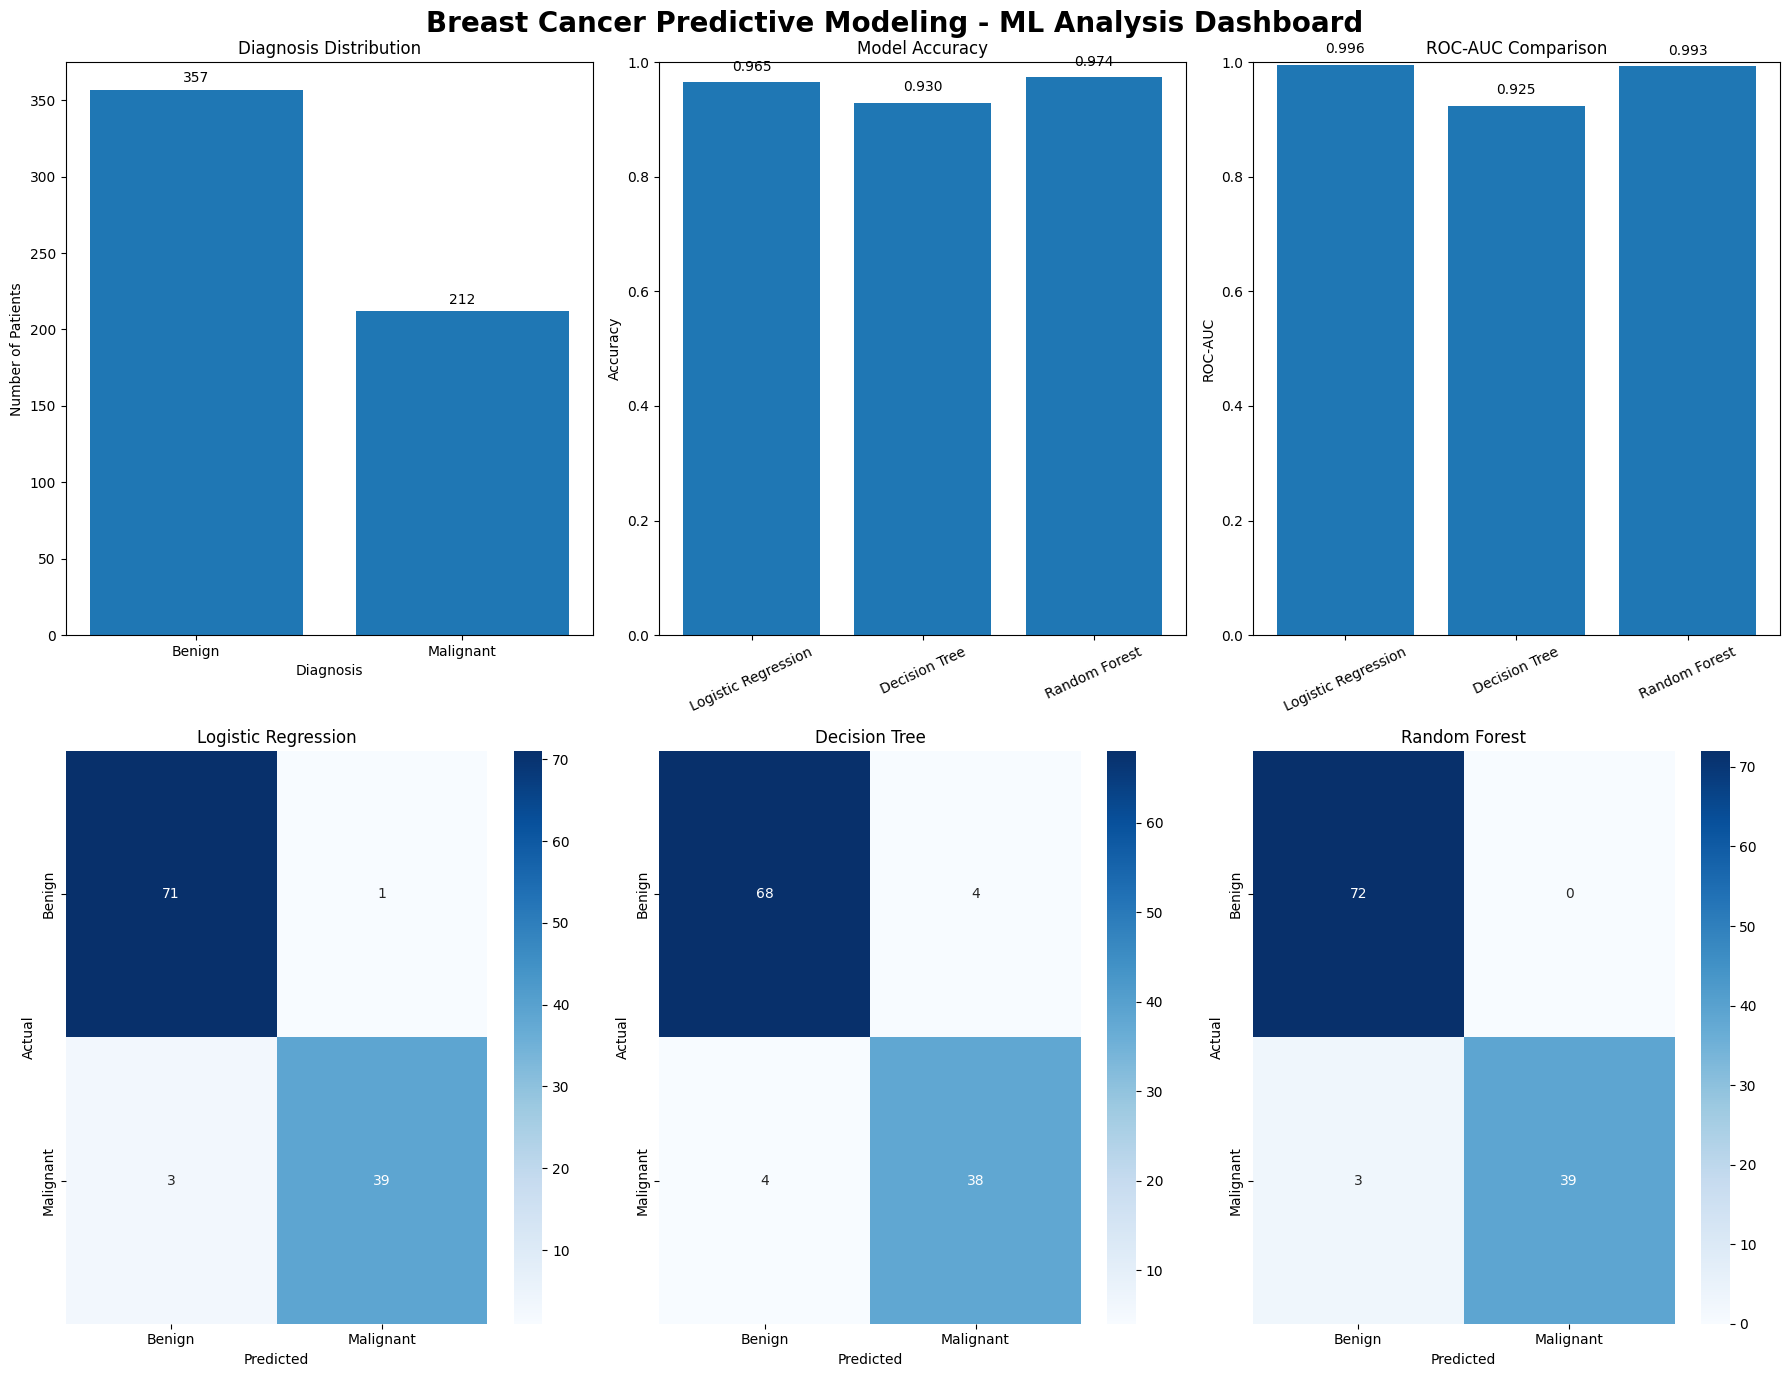

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig = plt.figure(figsize=(18, 14))

# -------------------------------------------------
# 1. Diagnosis Distribution
# -------------------------------------------------
ax1 = plt.subplot(2, 3, 1)

diagnosis_counts = y.value_counts().sort_index()

ax1.bar(
    ["Benign", "Malignant"],
    diagnosis_counts.values
)

ax1.set_title("Diagnosis Distribution")
ax1.set_xlabel("Diagnosis")
ax1.set_ylabel("Number of Patients")

for i, value in enumerate(diagnosis_counts.values):
    ax1.text(i, value + 5, str(value), ha="center")


# -------------------------------------------------
# 2. Model Accuracy
# -------------------------------------------------
ax2 = plt.subplot(2, 3, 2)

models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]

accuracies = [
    logistic_accuracy,
    tree_accuracy,
    forest_accuracy
]

ax2.bar(models, accuracies)

ax2.set_title("Model Accuracy")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1)

ax2.tick_params(axis="x", rotation=25)

for i, value in enumerate(accuracies):
    ax2.text(
        i,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )


# -------------------------------------------------
# 3. ROC-AUC Comparison
# -------------------------------------------------
ax3 = plt.subplot(2, 3, 3)

auc_values = [
    logistic_auc,
    tree_auc,
    forest_auc
]

ax3.bar(models, auc_values)

ax3.set_title("ROC-AUC Comparison")
ax3.set_ylabel("ROC-AUC")
ax3.set_ylim(0, 1)

ax3.tick_params(axis="x", rotation=25)

for i, value in enumerate(auc_values):
    ax3.text(
        i,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )


# -------------------------------------------------
# 4. Logistic Regression Confusion Matrix
# -------------------------------------------------
ax4 = plt.subplot(2, 3, 4)

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"],
    ax=ax4
)

ax4.set_title("Logistic Regression")
ax4.set_xlabel("Predicted")
ax4.set_ylabel("Actual")


# -------------------------------------------------
# 5. Decision Tree Confusion Matrix
# -------------------------------------------------
ax5 = plt.subplot(2, 3, 5)

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"],
    ax=ax5
)

ax5.set_title("Decision Tree")
ax5.set_xlabel("Predicted")
ax5.set_ylabel("Actual")


# -------------------------------------------------
# 6. Random Forest Confusion Matrix
# -------------------------------------------------
ax6 = plt.subplot(2, 3, 6)

sns.heatmap(
    cm_forest,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"],
    ax=ax6
)

ax6.set_title("Random Forest")
ax6.set_xlabel("Predicted")
ax6.set_ylabel("Actual")


plt.suptitle(
    "Breast Cancer Predictive Modeling - ML Analysis Dashboard",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

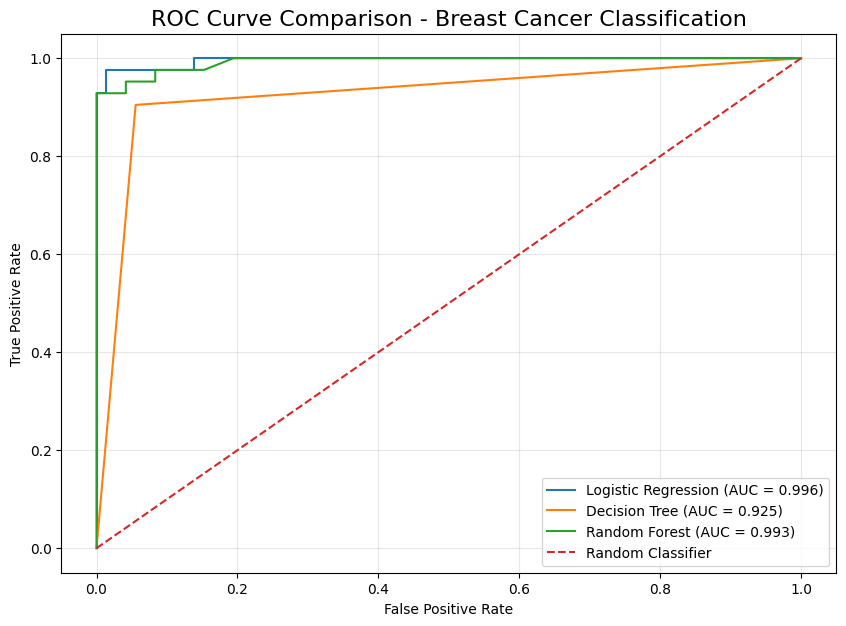

In [ ]:
plt.figure(figsize=(10, 7))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC = {tree_auc:.3f})"
)

plt.plot(
    fpr_forest,
    tpr_forest,
    label=f"Random Forest (AUC = {forest_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve Comparison - Breast Cancer Classification",
    fontsize=16
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

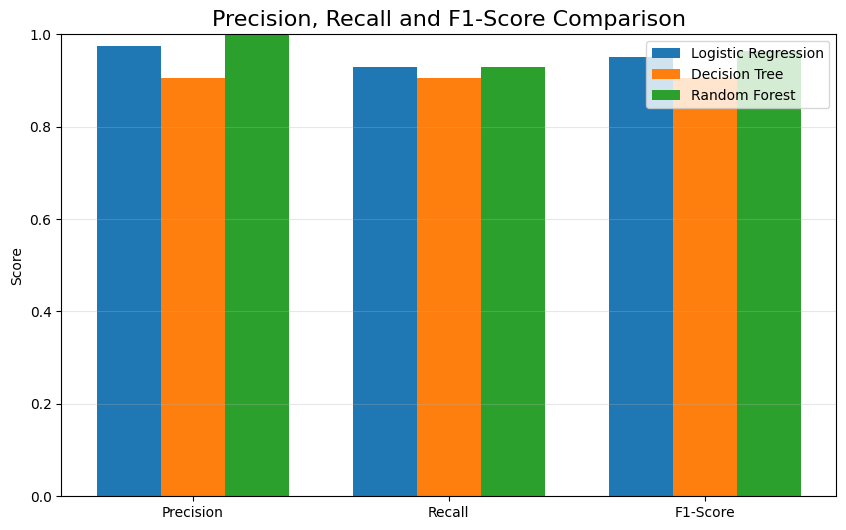

In [ ]:
metrics = ["Precision", "Recall", "F1-Score"]

logistic_metrics = [
    precision_score(y_test, y_pred_logistic),
    recall_score(y_test, y_pred_logistic),
    f1_score(y_test, y_pred_logistic)
]

tree_metrics = [
    precision_score(y_test, y_pred_tree),
    recall_score(y_test, y_pred_tree),
    f1_score(y_test, y_pred_tree)
]

forest_metrics = [
    precision_score(y_test, y_pred_forest),
    recall_score(y_test, y_pred_forest),
    f1_score(y_test, y_pred_forest)
]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(
    x - width,
    logistic_metrics,
    width,
    label="Logistic Regression"
)

plt.bar(
    x,
    tree_metrics,
    width,
    label="Decision Tree"
)

plt.bar(
    x + width,
    forest_metrics,
    width,
    label="Random Forest"
)

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0, 1)

plt.title(
    "Precision, Recall and F1-Score Comparison",
    fontsize=16
)

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

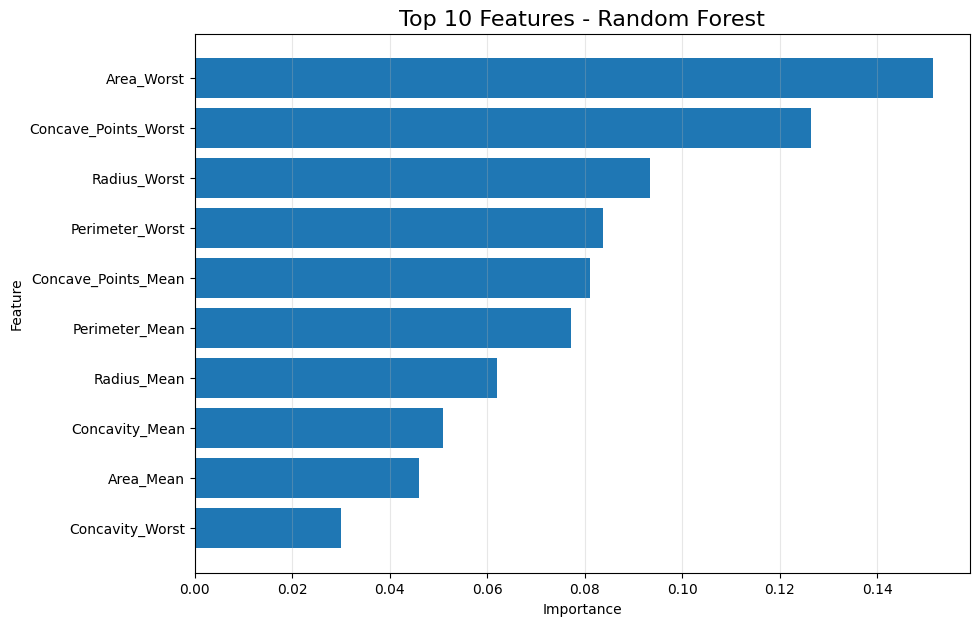

In [ ]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Top 10 Features - Random Forest",
    fontsize=16
)

plt.grid(axis="x", alpha=0.3)

plt.show()

In [ ]:
print("=" * 70)
print("BREAST CANCER PREDICTIVE MODELING - FINAL ANALYSIS")
print("=" * 70)

print(f"\nDataset Size       : {len(df)}")
print(f"Number of Features: {X.shape[1]}")
print(f"Training Samples   : {len(X_train)}")
print(f"Testing Samples    : {len(X_test)}")

print("\nMODEL PERFORMANCE")
print("-" * 70)

print(
    f"Logistic Regression | "
    f"Accuracy: {logistic_accuracy:.4f} | "
    f"ROC-AUC: {logistic_auc:.4f}"
)

print(
    f"Decision Tree       | "
    f"Accuracy: {tree_accuracy:.4f} | "
    f"ROC-AUC: {tree_auc:.4f}"
)

print(
    f"Random Forest       | "
    f"Accuracy: {forest_accuracy:.4f} | "
    f"ROC-AUC: {forest_auc:.4f}"
)

print("\nANALYSIS COMPLETED")
print("=" * 70)

BREAST CANCER PREDICTIVE MODELING - FINAL ANALYSIS

Dataset Size       : 569
Number of Features: 30
Training Samples   : 455
Testing Samples    : 114

MODEL PERFORMANCE
----------------------------------------------------------------------
Logistic Regression | Accuracy: 0.9649 | ROC-AUC: 0.9960
Decision Tree       | Accuracy: 0.9298 | ROC-AUC: 0.9246
Random Forest       | Accuracy: 0.9737 | ROC-AUC: 0.9929

ANALYSIS COMPLETED


In [ ]:
df
X
y
X_train
X_test
y_train
y_test

logistic_model
decision_tree_model
random_forest_model

logistic_accuracy
tree_accuracy
forest_accuracy

logistic_auc
tree_auc
forest_auc

cm_logistic
cm_tree
cm_forest

fpr_logistic
tpr_logistic
fpr_tree
tpr_tree
fpr_forest
tpr_forest

feature_importance
metrics_comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.964912,0.975000,0.928571,0.951220,0.996032
1,Decision Tree,0.929825,0.904762,0.904762,0.904762,0.924603
2,Random Forest,0.973684,1.000000,0.928571,0.962963,0.992890


In [ ]:
!pip install -q streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 73.9 MB/s eta 0:00:00


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

# ---------------------------------------------------------
# PAGE CONFIGURATION
# ---------------------------------------------------------

st.set_page_config(
    page_title="Breast Cancer ML Dashboard",
    page_icon="🩺",
    layout="wide"
)

# ---------------------------------------------------------
# TITLE
# ---------------------------------------------------------

st.title("🩺 Breast Cancer Predictive Modeling Dashboard")

st.markdown(
    "### Machine Learning Analysis using Logistic Regression, "
    "Decision Tree and Random Forest"
)

st.markdown("---")

# ---------------------------------------------------------
# MODEL DATA
# ---------------------------------------------------------

models = {
    "Logistic Regression": {
        "accuracy": logistic_accuracy,
        "auc": logistic_auc,
        "pred": y_pred_logistic,
        "prob": y_prob_logistic,
        "cm": cm_logistic,
        "fpr": fpr_logistic,
        "tpr": tpr_logistic
    },

    "Decision Tree": {
        "accuracy": tree_accuracy,
        "auc": tree_auc,
        "pred": y_pred_tree,
        "prob": y_prob_tree,
        "cm": cm_tree,
        "fpr": fpr_tree,
        "tpr": tpr_tree
    },

    "Random Forest": {
        "accuracy": forest_accuracy,
        "auc": forest_auc,
        "pred": y_pred_forest,
        "prob": y_prob_forest,
        "cm": cm_forest,
        "fpr": fpr_forest,
        "tpr": tpr_forest
    }
}

# ---------------------------------------------------------
# SIDEBAR
# ---------------------------------------------------------

st.sidebar.header("Dashboard Controls")

selected_model = st.sidebar.selectbox(
    "Select Machine Learning Model",
    list(models.keys())
)

model_data = models[selected_model]

# ---------------------------------------------------------
# KPI CARDS
# ---------------------------------------------------------

total_cases = len(df)
total_features = X.shape[1]
accuracy = model_data["accuracy"]
auc = model_data["auc"]

col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric(
        "Total Cases",
        total_cases
    )

with col2:
    st.metric(
        "Features",
        total_features
    )

with col3:
    st.metric(
        "Accuracy",
        f"{accuracy * 100:.2f}%"
    )

with col4:
    st.metric(
        "ROC-AUC",
        f"{auc:.4f}"
    )

st.markdown("---")

# ---------------------------------------------------------
# ROW 1
# ---------------------------------------------------------

col1, col2 = st.columns(2)

# Diagnosis Distribution
with col1:

    st.subheader("Diagnosis Distribution")

    diagnosis_counts = y.value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.bar(
        ["Benign", "Malignant"],
        diagnosis_counts.values
    )

    ax.set_ylabel("Number of Cases")
    ax.set_xlabel("Diagnosis")
    ax.set_title("Benign vs Malignant Cases")

    for i, value in enumerate(diagnosis_counts.values):
        ax.text(
            i,
            value + 5,
            str(value),
            ha="center"
        )

    st.pyplot(fig)

# Model Accuracy
with col2:

    st.subheader("Model Accuracy Comparison")

    model_names = list(models.keys())

    accuracy_values = [
        models[m]["accuracy"]
        for m in model_names
    ]

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.bar(
        model_names,
        accuracy_values
    )

    ax.set_ylim(0, 1)
    ax.set_ylabel("Accuracy")
    ax.set_title("Accuracy Comparison")

    ax.tick_params(
        axis="x",
        rotation=20
    )

    for i, value in enumerate(accuracy_values):

        ax.text(
            i,
            value + 0.02,
            f"{value:.3f}",
            ha="center"
        )

    st.pyplot(fig)

# ---------------------------------------------------------
# ROW 2
# ---------------------------------------------------------

col1, col2 = st.columns(2)

# Confusion Matrix
with col1:

    st.subheader(
        f"{selected_model} - Confusion Matrix"
    )

    fig, ax = plt.subplots(
        figsize=(6, 5)
    )

    sns.heatmap(
        model_data["cm"],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Benign", "Malignant"],
        yticklabels=["Benign", "Malignant"],
        ax=ax
    )

    ax.set_xlabel("Predicted Diagnosis")
    ax.set_ylabel("Actual Diagnosis")

    st.pyplot(fig)

# ROC Curve
with col2:

    st.subheader("ROC Curve Comparison")

    fig, ax = plt.subplots(
        figsize=(7, 5)
    )

    for name, data in models.items():

        ax.plot(
            data["fpr"],
            data["tpr"],
            label=f"{name} (AUC={data['auc']:.3f})"
        )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")

    ax.set_title(
        "ROC Curve - All Models"
    )

    ax.legend()

    st.pyplot(fig)

# ---------------------------------------------------------
# ROW 3
# ---------------------------------------------------------

col1, col2 = st.columns(2)

# Precision Recall F1
with col1:

    st.subheader(
        f"{selected_model} - Performance Metrics"
    )

    predictions = model_data["pred"]

    precision = precision_score(
        y_test,
        predictions
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    metric_names = [
        "Precision",
        "Recall",
        "F1-Score"
    ]

    metric_values = [
        precision,
        recall,
        f1
    ]

    fig, ax = plt.subplots(
        figsize=(7, 5)
    )

    ax.bar(
        metric_names,
        metric_values
    )

    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.set_title(
        "Classification Metrics"
    )

    for i, value in enumerate(metric_values):

        ax.text(
            i,
            value + 0.02,
            f"{value:.3f}",
            ha="center"
        )

    st.pyplot(fig)

# Feature Importance
with col2:

    st.subheader(
        "Top 10 Feature Importance"
    )

    top_features = feature_importance.head(10)

    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    ax.barh(
        top_features["Feature"][::-1],
        top_features["Importance"][::-1]
    )

    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")

    ax.set_title(
        "Random Forest Feature Importance"
    )

    st.pyplot(fig)

# ---------------------------------------------------------
# MODEL PERFORMANCE TABLE
# ---------------------------------------------------------

st.markdown("---")

st.subheader("📊 Complete Model Performance")

display_table = metrics_comparison.copy()

display_table[
    ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
] = display_table[
    ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
].round(4)

st.dataframe(
    display_table,
    use_container_width=True,
    hide_index=True
)

# ---------------------------------------------------------
# DATASET INFORMATION
# ---------------------------------------------------------

st.markdown("---")

st.subheader("📁 Dataset Information")

info_col1, info_col2, info_col3 = st.columns(3)

with info_col1:
    st.write("**Dataset:** Breast Cancer Wisconsin (Diagnostic)")

with info_col2:
    st.write(f"**Training Samples:** {len(X_train)}")

with info_col3:
    st.write(f"**Testing Samples:** {len(X_test)}")

st.success(
    "Dashboard successfully generated using Python and Streamlit."
)

Writing app.py


In [ ]:
!streamlit run app.py &>/content/streamlit.log &

In [ ]:
import joblib

dashboard_data = {
    "df": df,
    "X": X,
    "y": y,
    "X_train": X_train,
    "X_test": X_test,
    "y_train": y_train,
    "y_test": y_test,

    "logistic_accuracy": logistic_accuracy,
    "tree_accuracy": tree_accuracy,
    "forest_accuracy": forest_accuracy,

    "logistic_auc": logistic_auc,
    "tree_auc": tree_auc,
    "forest_auc": forest_auc,

    "y_pred_logistic": y_pred_logistic,
    "y_pred_tree": y_pred_tree,
    "y_pred_forest": y_pred_forest,

    "y_prob_logistic": y_prob_logistic,
    "y_prob_tree": y_prob_tree,
    "y_prob_forest": y_prob_forest,

    "cm_logistic": cm_logistic,
    "cm_tree": cm_tree,
    "cm_forest": cm_forest,

    "fpr_logistic": fpr_logistic,
    "tpr_logistic": tpr_logistic,
    "fpr_tree": fpr_tree,
    "tpr_tree": tpr_tree,
    "fpr_forest": fpr_forest,
    "tpr_forest": tpr_forest,

    "feature_importance": feature_importance,
    "metrics_comparison": metrics_comparison
}

joblib.dump(
    dashboard_data,
    "dashboard_data.pkl"
)

print("Dashboard data saved successfully!")

Dashboard data saved successfully!


In [ ]:
import os

print(
    "dashboard_data.pkl exists:",
    os.path.exists("dashboard_data.pkl")
)

print(
    "File size:",
    round(os.path.getsize("dashboard_data.pkl") / 1024, 2),
    "KB"
)

dashboard_data.pkl exists: True
File size: 448.98 KB


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

# =========================================================
# LOAD DASHBOARD DATA
# =========================================================

data = joblib.load("dashboard_data.pkl")

df = data["df"]
X = data["X"]
y = data["y"]
X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

logistic_accuracy = data["logistic_accuracy"]
tree_accuracy = data["tree_accuracy"]
forest_accuracy = data["forest_accuracy"]

logistic_auc = data["logistic_auc"]
tree_auc = data["tree_auc"]
forest_auc = data["forest_auc"]

y_pred_logistic = data["y_pred_logistic"]
y_pred_tree = data["y_pred_tree"]
y_pred_forest = data["y_pred_forest"]

y_prob_logistic = data["y_prob_logistic"]
y_prob_tree = data["y_prob_tree"]
y_prob_forest = data["y_prob_forest"]

cm_logistic = data["cm_logistic"]
cm_tree = data["cm_tree"]
cm_forest = data["cm_forest"]

fpr_logistic = data["fpr_logistic"]
tpr_logistic = data["tpr_logistic"]

fpr_tree = data["fpr_tree"]
tpr_tree = data["tpr_tree"]

fpr_forest = data["fpr_forest"]
tpr_forest = data["tpr_forest"]

feature_importance = data["feature_importance"]
metrics_comparison = data["metrics_comparison"]


# =========================================================
# PAGE CONFIGURATION
# =========================================================

st.set_page_config(
    page_title="Breast Cancer ML Dashboard",
    page_icon="🩺",
    layout="wide"
)


# =========================================================
# CUSTOM CSS
# =========================================================

st.markdown("""
<style>

.main {
    background-color: #f7f9fc;
}

.block-container {
    padding-top: 1.5rem;
}

h1 {
    font-weight: 700;
}

[data-testid="stMetric"] {
    background-color: white;
    padding: 15px;
    border-radius: 10px;
    border: 1px solid #e5e7eb;
}

</style>
""", unsafe_allow_html=True)


# =========================================================
# HEADER
# =========================================================

st.title("🩺 Breast Cancer Predictive Modeling Dashboard")

st.markdown(
    "### Machine Learning Analysis using Logistic Regression, "
    "Decision Tree and Random Forest"
)

st.markdown("---")


# =========================================================
# MODEL SELECTION
# =========================================================

st.sidebar.title("Dashboard Controls")

selected_model = st.sidebar.selectbox(
    "Select Model",
    [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ]
)


# =========================================================
# MODEL INFORMATION
# =========================================================

models = {

    "Logistic Regression": {
        "accuracy": logistic_accuracy,
        "auc": logistic_auc,
        "pred": y_pred_logistic,
        "cm": cm_logistic,
        "fpr": fpr_logistic,
        "tpr": tpr_logistic
    },

    "Decision Tree": {
        "accuracy": tree_accuracy,
        "auc": tree_auc,
        "pred": y_pred_tree,
        "cm": cm_tree,
        "fpr": fpr_tree,
        "tpr": tpr_tree
    },

    "Random Forest": {
        "accuracy": forest_accuracy,
        "auc": forest_auc,
        "pred": y_pred_forest,
        "cm": cm_forest,
        "fpr": fpr_forest,
        "tpr": tpr_forest
    }
}

model_data = models[selected_model]


# =========================================================
# KPI CARDS
# =========================================================

st.subheader("📌 Key Performance Indicators")

col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric(
        "Total Cases",
        len(df)
    )

with col2:
    st.metric(
        "Features",
        X.shape[1]
    )

with col3:
    st.metric(
        "Model Accuracy",
        f"{model_data['accuracy'] * 100:.2f}%"
    )

with col4:
    st.metric(
        "ROC-AUC",
        f"{model_data['auc']:.4f}"
    )


st.markdown("---")


# =========================================================
# ROW 1
# =========================================================

col1, col2 = st.columns(2)


# ---------------------------------------------------------
# DIAGNOSIS DISTRIBUTION
# ---------------------------------------------------------

with col1:

    st.subheader("Diagnosis Distribution")

    diagnosis_counts = y.value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.bar(
        ["Benign", "Malignant"],
        diagnosis_counts.values
    )

    ax.set_ylabel("Number of Cases")
    ax.set_xlabel("Diagnosis")

    for i, value in enumerate(diagnosis_counts.values):

        ax.text(
            i,
            value + 5,
            str(value),
            ha="center"
        )

    st.pyplot(fig)
    plt.close(fig)


# ---------------------------------------------------------
# MODEL ACCURACY
# ---------------------------------------------------------

with col2:

    st.subheader("Model Accuracy Comparison")

    model_names = list(models.keys())

    accuracy_values = [
        models[m]["accuracy"]
        for m in model_names
    ]

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.bar(
        model_names,
        accuracy_values
    )

    ax.set_ylim(0, 1)
    ax.set_ylabel("Accuracy")

    ax.tick_params(
        axis="x",
        rotation=20
    )

    for i, value in enumerate(accuracy_values):

        ax.text(
            i,
            value + 0.02,
            f"{value:.3f}",
            ha="center"
        )

    st.pyplot(fig)
    plt.close(fig)


# =========================================================
# ROW 2
# =========================================================

col1, col2 = st.columns(2)


# ---------------------------------------------------------
# CONFUSION MATRIX
# ---------------------------------------------------------

with col1:

    st.subheader(
        f"{selected_model} - Confusion Matrix"
    )

    fig, ax = plt.subplots(figsize=(6, 5))

    sns.heatmap(
        model_data["cm"],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[
            "Benign",
            "Malignant"
        ],
        yticklabels=[
            "Benign",
            "Malignant"
        ],
        ax=ax
    )

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    st.pyplot(fig)
    plt.close(fig)


# ---------------------------------------------------------
# ROC CURVE
# ---------------------------------------------------------

with col2:

    st.subheader("ROC Curve Comparison")

    fig, ax = plt.subplots(figsize=(7, 5))

    for name, model in models.items():

        ax.plot(
            model["fpr"],
            model["tpr"],
            label=f"{name} (AUC={model['auc']:.3f})"
        )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Random Classifier"
    )

    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")

    ax.legend()

    st.pyplot(fig)
    plt.close(fig)


# =========================================================
# ROW 3
# =========================================================

col1, col2 = st.columns(2)


# ---------------------------------------------------------
# PRECISION RECALL F1
# ---------------------------------------------------------

with col1:

    st.subheader(
        f"{selected_model} - Classification Metrics"
    )

    predictions = model_data["pred"]

    precision = precision_score(
        y_test,
        predictions
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    metric_names = [
        "Precision",
        "Recall",
        "F1-Score"
    ]

    metric_values = [
        precision,
        recall,
        f1
    ]

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.bar(
        metric_names,
        metric_values
    )

    ax.set_ylim(0, 1)
    ax.set_ylabel("Score")

    for i, value in enumerate(metric_values):

        ax.text(
            i,
            value + 0.02,
            f"{value:.3f}",
            ha="center"
        )

    st.pyplot(fig)
    plt.close(fig)


# ---------------------------------------------------------
# FEATURE IMPORTANCE
# ---------------------------------------------------------

with col2:

    st.subheader("Top 10 Feature Importance")

    top_features = feature_importance.head(10)

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.barh(
        top_features["Feature"][::-1],
        top_features["Importance"][::-1]
    )

    ax.set_xlabel("Importance")

    st.pyplot(fig)
    plt.close(fig)


# =========================================================
# MODEL PERFORMANCE TABLE
# =========================================================

st.markdown("---")

st.subheader("📊 Complete Model Performance")

display_table = metrics_comparison.copy()

numeric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

display_table[numeric_columns] = (
    display_table[numeric_columns].round(4)
)

st.dataframe(
    display_table,
    use_container_width=True,
    hide_index=True
)


# =========================================================
# DATASET INFORMATION
# =========================================================

st.markdown("---")

st.subheader("📁 Dataset Information")

col1, col2, col3 = st.columns(3)

with col1:
    st.write(
        "**Dataset:** Breast Cancer Wisconsin (Diagnostic)"
    )

with col2:
    st.write(
        f"**Training Samples:** {len(X_train)}"
    )

with col3:
    st.write(
        f"**Testing Samples:** {len(X_test)}"
    )


st.markdown("---")

st.success(
    "Interactive dashboard generated successfully using Python + Streamlit."
)

Overwriting app.py


In [ ]:
!streamlit run app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.headless true \
    > /content/streamlit.log 2>&1 &

In [ ]:
from google.colab.output import eval_js

url = eval_js(
    "google.colab.kernel.proxyPort(8501)"
)

print("Dashboard URL:")
print(url)

Dashboard URL:
https://8501-m-s-kkb-ass1c0-2n5mb5sy9eypk-c.asia-southeast1-0.prod.colab.dev


In [ ]:
print(open("/content/streamlit.log").read())



2026-09-26 16:09:09.834 Port 8501 is not available
                                                                                                                                                                                     2026-09-26 16:09:30.403 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-ass1c0-2n5mb5sy9eypk-c.asia-southeast1-0.prod.colab.dev, host=m-s-kkb-ass1c0-2n5mb5sy9eypk.asia-southeast1-c.c.codatalab-user-runtimes.internal:8007
2026-09-26 16:09:31.267 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-ass1c0-2n5mb5sy9eypk-c.asia-southeast1-0.prod.colab.dev, host=m-s-kkb-ass1c0-2n5mb5sy9eypk.asia-southeast1-c.c.codatalab-user-runtimes.internal:8007
2026-09-26 16:09:32.725 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-ass1c0-2n5mb5sy9eypk-c.asia-southeast1-0.prod.colab.dev, host=m-s-kkb-ass1c0-2n5mb5sy9eypk.asia-southe

In [ ]:
!pkill -f streamlit || true

^C


In [ ]:
!streamlit run /content/app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.headless true \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    > /content/streamlit.log 2>&1 &

In [ ]:
import time
import requests

time.sleep(5)

try:
    response = requests.get("http://127.0.0.1:8501")
    print("Streamlit is running!")
    print("Status code:", response.status_code)
except Exception as e:
    print("Streamlit did not start:")
    print(e)

Streamlit is running!
Status code: 200


In [ ]:
from google.colab.output import eval_js

dashboard_url = eval_js(
    "google.colab.kernel.proxyPort(8501)"
)

print("OPEN THIS LINK:")
print(dashboard_url)

OPEN THIS LINK:
https://8501-m-s-kkb-ass1c0-2n5mb5sy9eypk-c.asia-southeast1-0.prod.colab.dev


In [ ]:
# =========================================================
# PROFESSIONAL DASHBOARD THEME
# =========================================================

app_path = "/content/app.py"

with open(app_path, "r") as f:
    app_code = f.read()


# ---------------------------------------------------------
# REPLACE THE OLD CSS
# ---------------------------------------------------------

old_css = '''st.markdown("""
<style>

.main {
    background-color: #f7f9fc;
}

.block-container {
    padding-top: 1.5rem;
}

h1 {
    font-weight: 700;
}

[data-testid="stMetric"] {
    background-color: white;
    padding: 15px;
    border-radius: 10px;
    border: 1px solid #e5e7eb;
}

</style>
""", unsafe_allow_html=True)
'''


new_css = '''st.markdown("""
<style>

/* =========================================
   GLOBAL PAGE
   ========================================= */

.stApp {
    background: #f4f7fb;
}

.block-container {
    padding-top: 2rem;
    padding-bottom: 3rem;
    max-width: 1500px;
}


/* =========================================
   MAIN TITLE
   ========================================= */

h1 {
    color: #0f172a;
    font-size: 2.5rem !important;
    font-weight: 800 !important;
    letter-spacing: -1px;
}

h2, h3 {
    color: #172554;
    font-weight: 700 !important;
}


/* =========================================
   SIDEBAR
   ========================================= */

section[data-testid="stSidebar"] {
    background: linear-gradient(
        180deg,
        #0f172a 0%,
        #172554 100%
    );
}

section[data-testid="stSidebar"] * {
    color: #f8fafc !important;
}

section[data-testid="stSidebar"] h1,
section[data-testid="stSidebar"] h2,
section[data-testid="stSidebar"] h3 {
    color: #ffffff !important;
}

section[data-testid="stSidebar"] .stSelectbox label {
    color: #cbd5e1 !important;
    font-weight: 600;
}


/* =========================================
   KPI CARDS
   ========================================= */

[data-testid="stMetric"] {
    background: #ffffff;
    padding: 22px 24px;
    border-radius: 14px;
    border: 1px solid #dbe4f0;
    box-shadow: 0 4px 15px rgba(15, 23, 42, 0.07);
    transition: all 0.2s ease;
}

[data-testid="stMetric"]:hover {
    transform: translateY(-3px);
    box-shadow: 0 8px 22px rgba(15, 23, 42, 0.12);
}

[data-testid="stMetricLabel"] {
    color: #64748b !important;
    font-size: 0.9rem !important;
    font-weight: 600 !important;
}

[data-testid="stMetricValue"] {
    color: #0f172a !important;
    font-weight: 800 !important;
}


/* =========================================
   CHART / CONTENT CONTAINERS
   ========================================= */

div[data-testid="stVerticalBlock"] {
    border-radius: 12px;
}


/* =========================================
   DATAFRAME
   ========================================= */

[data-testid="stDataFrame"] {
    border-radius: 12px;
    overflow: hidden;
    border: 1px solid #dbe4f0;
    box-shadow: 0 3px 12px rgba(15, 23, 42, 0.05);
}


/* =========================================
   SELECT BOX
   ========================================= */

div[data-baseweb="select"] > div {
    border-radius: 10px !important;
    border: 1px solid #475569 !important;
    background: #1e293b !important;
}


/* =========================================
   SUCCESS MESSAGE
   ========================================= */

div[data-testid="stAlert"] {
    border-radius: 12px;
}


/* =========================================
   DIVIDERS
   ========================================= */

hr {
    border: none;
    height: 1px;
    background: #dbe4f0;
    margin: 25px 0;
}


/* =========================================
   SCROLLBAR
   ========================================= */

::-webkit-scrollbar {
    width: 8px;
}

::-webkit-scrollbar-track {
    background: #e2e8f0;
}

::-webkit-scrollbar-thumb {
    background: #64748b;
    border-radius: 10px;
}

</style>
""", unsafe_allow_html=True)
'''


if old_css in app_code:
    app_code = app_code.replace(old_css, new_css)
else:
    print("Old CSS block was not found.")


# ---------------------------------------------------------
# ADD PROFESSIONAL MATPLOTLIB STYLE
# ---------------------------------------------------------

matplotlib_code = '''

# =========================================================
# PROFESSIONAL CHART STYLE
# =========================================================

plt.rcParams.update({
    "figure.facecolor": "#ffffff",
    "axes.facecolor": "#ffffff",
    "axes.edgecolor": "#dbe4f0",
    "axes.labelcolor": "#334155",
    "axes.titlecolor": "#0f172a",
    "xtick.color": "#475569",
    "ytick.color": "#475569",
    "text.color": "#0f172a",
    "font.size": 10,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.color": "#e2e8f0",
    "grid.alpha": 0.7
})

'''


marker = '# =========================================================\n# PAGE CONFIGURATION\n# ========================================================='

if matplotlib_code.strip() not in app_code:
    app_code = app_code.replace(
        marker,
        matplotlib_code + "\n" + marker
    )


# ---------------------------------------------------------
# REPLACE TITLE WITH PROFESSIONAL HEADER
# ---------------------------------------------------------

old_title = '''st.title("🩺 Breast Cancer Predictive Modeling Dashboard")

st.markdown(
    "### Machine Learning Analysis using Logistic Regression, "
    "Decision Tree and Random Forest"
)
'''

new_title = '''st.markdown("""
<div style="
    background: linear-gradient(135deg, #0f172a, #1e3a8a);
    padding: 28px 35px;
    border-radius: 18px;
    margin-bottom: 25px;
    box-shadow: 0 8px 25px rgba(15, 23, 42, 0.18);
">

<div style="
    color: #ffffff;
    font-size: 32px;
    font-weight: 800;
    letter-spacing: -0.5px;
">
🩺 Breast Cancer Predictive Modeling
</div>

<div style="
    color: #cbd5e1;
    font-size: 16px;
    margin-top: 8px;
">
Machine Learning Dashboard • Logistic Regression • Decision Tree • Random Forest
</div>

</div>
""", unsafe_allow_html=True)
'''

if old_title in app_code:
    app_code = app_code.replace(
        old_title,
        new_title
    )


# ---------------------------------------------------------
# SAVE UPDATED APP
# ---------------------------------------------------------

with open(app_path, "w") as f:
    f.write(app_code)

print("Professional dashboard theme applied successfully!")

Professional dashboard theme applied successfully!


In [ ]:
!pkill -f streamlit || true

^C


In [ ]:
!streamlit run /content/app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.headless true \
    --server.enableCORS false \
    --server.enableXsrfProtection false \
    > /content/streamlit.log 2>&1 &

In [ ]:
from google.colab.output import eval_js

dashboard_url = eval_js(
    "google.colab.kernel.proxyPort(8501)"
)

print("OPEN UPDATED DASHBOARD:")
print(dashboard_url)

OPEN UPDATED DASHBOARD:
https://8501-m-s-kkb-ass1c0-2n5mb5sy9eypk-c.asia-southeast1-0.prod.colab.dev
